# Optimisers for variational circuits — update rules and a benchmark on GHZ preparation and the Ising chain

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

The previous notebook,
[40 — parametrized gates and gradients](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb),
built the quantum half of the variational loop: a circuit $U(\boldsymbol\theta)$, a cost
$C(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert\hat O\vert\psi(\boldsymbol\theta)\rangle$, and four ways to
obtain $\nabla C$. This notebook builds the classical half — the rule that turns a gradient into the next set of angles —
and then measures which rules actually work.

Three features of variational quantum algorithms make the choice of this rule more delicate than in an ordinary
smooth minimisation.

1. **Every evaluation is expensive.** On hardware a single number $C(\boldsymbol\theta)$ costs thousands of circuit
   executions. An optimiser that converges in 50 iterations but needs $2n$ circuits per iteration may be worse than one
   that needs 500 iterations and 2 circuits.
2. **The cost is noisy.** It is an average over a finite number of measurements, so the "function" being minimised is a
   random variable. Classical optimisers built on the assumption of exact function values — line searches, quasi-Newton
   curvature estimates — degrade badly.
3. **The landscape is not convex.** Section 6 of the previous notebook showed that the cost is a bounded trigonometric
   polynomial of the angles, and its two-angle map already has several local minima. Section 14 below measures how
   often random starts end in one of them, and how that depends on the circuit depth.

**Road map.** Every optimiser is introduced the same way: the update equation, a derivation or a motivation for it, a
from-scratch implementation in engine style, and a measurement.

1. **The quadratic model** and what "curvature" means for a circuit landscape (Section 3).
2. **Gradient descent** with the stability condition $\eta<2/L$ derived on a quadratic and measured both on a quadratic
   and on a real circuit Hessian (Section 4).
3. **Heavy-ball momentum**, its two-term recursion and the $\sqrt\kappa$ speed-up (Section 5).
4. **Adam**, with the bias correction derived rather than quoted (Section 6).
5. **SPSA with Spall's gain sequences** $a_k=a/(k+A)^\alpha$, $c_k=c/k^\gamma$, and where the numbers $\alpha=0.602$,
   $\gamma=0.101$ come from (Section 7); the **SPSA–Adam hybrid** (Section 8).
6. **The quantum natural gradient**: the Fubini–Study metric, derived from the fidelity between neighbouring states,
   validated against an analytic single-qubit case and against the fidelity expansion itself (Section 9).
7. **Training loops** compiled with `lax.scan` and batched over random initialisations with `vmap` (Section 10), and a
   learning-rate sweep so that every hyper-parameter used later is one that was *measured* to be good (Section 11).
8. **Benchmark 1**: preparing a GHZ state by fidelity maximisation — medians and quantile bands over 24 random starts,
   iterations and circuit evaluations to a target accuracy, success probability with a confidence interval (Section 12).
9. **Benchmark 2**: the ground energy of a transverse-field Ising chain against the exact Lanczos value, with exact
   costs, a longer iteration budget as a control, and shot-noisy costs at three shot budgets (Section 13).
10. **Local minima and depth**: success probability against the number of layers, on a hard Haar-random target
    (Section 14), and a practical guidance table containing only what was measured (Section 15).

### What you will learn

*Physics and optimisation theory*

* why the largest curvature of the landscape sets a hard upper bound on the step size of gradient descent (and, with a
  different constant, of heavy-ball momentum), why Adam has no such threshold, and why the *condition number* sets the
  convergence rate;
* why momentum turns a rate $1-2/\kappa$ into $1-2/\sqrt\kappa$, and what that means in iterations;
* why a stochastic gradient forces a *decreasing* step size, and which decay exponents are admissible;
* what the quantum natural gradient corrects: the difference between distance in *parameter* space and distance in
  *state* space;
* why adding layers beyond the minimum needed can make the problem easier rather than harder.

*Numerical methods*

* writing an optimiser as a pair `(init, update)` of pure functions so that it can be carried through `lax.scan`;
* compiling a whole training run into one XLA program and batching random restarts with `vmap`;
* reporting medians and interquartile bands instead of one lucky run, and censoring runs that never reach the target;
* making a hyper-parameter choice by measurement rather than by folklore.

*Implementation practice*

* `lax.scan` with a loop counter as `xs`, so that iteration-dependent gain schedules compile;
* nested `vmap` (over learning rates and over initialisations) so that a sweep over eight learning rates compiles once
  per optimiser instead of eight times;
* timing a compiled program with its compilation separated from its run (`jit(...).lower(...).compile()`);
* `jax.jacfwd` through a circuit to build a metric tensor, and `jnp.linalg.solve` with a regulariser inside a scan.

### Prerequisites

* [40 — parametrized gates and gradients](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb):
  ansätze, cost functions, the parameter-shift rule, SPSA, reverse-mode AD, shot noise;
* [11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb):
  Hamiltonians as term lists and the exact ground state from Lanczos;
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  fidelity between pure states;
* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan`, `grad`,
  `jacfwd`, PRNG keys.

**What comes next.**
[42 — the variational quantum eigensolver](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb)
puts the circuit of notebook 40 and the optimisers of this notebook together into the full algorithm and studies the
physics of the optimised state — energy, fidelity and entanglement against the exact ground state, the effect of depth,
and statistics over random starts.

**Conventions and sizes.** All costs are minimised. Benchmarks use $N=4$ and $N=6$ qubits with a hardware-efficient
ansatz, so a full training run of hundreds of iterations and dozens of restarts fits comfortably in one compiled
program.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

We need the ansatz and its parameter count, the cost ingredients (`fidelity_pure`, `energy`, `heisenberg_terms`),
`lanczos_ground_state` for the exact reference energy of Benchmark 2, `sample_bitstrings` for the shot-noisy costs,
and the engine's `adam_init`/`adam_update` as the reference implementation that our from-scratch Adam must reproduce.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi

def adam_init(theta):
    """Adam state: (first moment m, second moment v, step counter t)."""
    return (jnp.zeros_like(theta), jnp.zeros_like(theta), 0)

def adam_update(theta, g, state, lr=0.05, b1=0.9, b2=0.999, eps=1e-8):
    """One Adam step (Kingma & Ba):  m <- b1 m + (1-b1) g,  v <- b2 v + (1-b2) g^2,
        theta <- theta - lr * m_hat / (sqrt(v_hat) + eps),   hats = bias-corrected moments.
    Momentum (m) averages noisy gradients (great with SPSA); v gives a per-parameter step size."""
    m, v, t = state
    t = t + 1
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g ** 2
    theta = theta - lr * (m / (1 - b1 ** t)) / (jnp.sqrt(v / (1 - b2 ** t)) + eps)
    return theta, (m, v, t)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def bands(hist):
    """Median and interquartile band of a batch of histories, shape (n_runs, n_steps) -> three curves."""
    h = np.asarray(hist)
    return np.percentile(h, 25, axis=0), np.median(h, axis=0), np.percentile(h, 75, axis=0)


def iterations_to(hist, target):
    """First iteration (1-based) at which the monitored quantity falls below `target`; -1 if it never does.

    IMPLEMENTATION  `argmax` on a boolean array returns the index of the FIRST True; the `any` mask censors runs
                    that never succeeded, so they can be excluded from the median instead of biasing it.
    """
    h = np.asarray(hist)
    below = h < target
    first = np.argmax(below, axis=1) + 1
    return np.where(below.any(axis=1), first, -1)


def summarise(name, hist, target, evals_per_iter):
    """One row of a benchmark table: success rate, median iterations and median circuit evaluations to `target`."""
    it = iterations_to(hist, target)
    ok = it > 0
    med = float(np.median(it[ok])) if ok.any() else float("nan")
    return dict(name=name, success=float(ok.mean()), iters=med, evals=med * evals_per_iter,
                best=float(np.min(np.asarray(hist)[:, -1])), median_final=float(np.median(np.asarray(hist)[:, -1])))

## 3. The optimisation problem and the quadratic model

We must minimise a smooth bounded function $C:\mathbb R^n\to\mathbb R$ given (noisy) access to its value and gradient.
Near any point $\boldsymbol\theta_0$ the Taylor expansion is

$$C(\boldsymbol\theta_0+\boldsymbol\delta)=C(\boldsymbol\theta_0)+\mathbf g^{\mathsf T}\boldsymbol\delta
  +\tfrac12\boldsymbol\delta^{\mathsf T}\mathbf H\boldsymbol\delta+O(\delta^3),
  \qquad g_i=\partial_iC,\quad H_{ij}=\partial_i\partial_jC. \tag{1}$$

Every statement about step sizes in this notebook comes from the quadratic truncation of Eq. (1). The Hessian $\mathbf H$
is symmetric, so it has real eigenvalues $\lambda_1\le\dots\le\lambda_n$; near a minimum they are non-negative. Two
numbers govern everything:

* $L\equiv\lambda_{\max}$, the **largest curvature** — it limits how large a step can be before the update overshoots;
* $\kappa\equiv\lambda_{\max}/\lambda_{\min}$, the **condition number** — it limits how fast the error can shrink.

For a circuit landscape both are computable: $C$ is an ordinary JAX function, so `jax.hessian` returns
$\mathbf H$ exactly. On hardware neither is available cheaply, which is why the optimisers below are built to
need as little curvature information as possible.

### Test problem: a diagonal quadratic

To test optimisers against theory we need a problem whose answer we know. Take

$$f(\mathbf x)=\tfrac12\sum_{i}\lambda_ix_i^2 ,\qquad \nabla f=\boldsymbol\lambda\odot\mathbf x, \tag{2}$$

whose Hessian is $\mathrm{diag}(\boldsymbol\lambda)$, whose minimum is $\mathbf x=0$ with $f=0$, and whose condition
number is $\kappa=\lambda_{\max}/\lambda_{\min}$ by construction. Any quadratic with a symmetric Hessian is equivalent to this one
after an orthogonal change of variables, so nothing is lost.

In [4]:
# ==============================================================================
# STEP 1: the optimiser interface, and the quadratic test problem
# ==============================================================================
# An OPTIMISER is a pair of pure functions:
#     init(theta)                      -> opt_state  (a pytree)
#     update(theta, opt_state, g, k)   -> (theta_new, opt_state_new)
# `k` is the 1-based iteration counter, needed by the schedules of Sections 6 and 7.
# A GRADIENT RULE is one function:
#     grad(theta, key, k)              -> gradient estimate
# `key` is a PRNG key (used only by stochastic rules), `k` the iteration counter (used by gain schedules).


def quadratic(lams):
    """The test problem of Eq. (2): returns (f, grad_f) for f(x) = 0.5 sum_i lam_i x_i^2."""
    lams = jnp.asarray(lams, dtype=RDTYPE)
    return (lambda x: 0.5 * jnp.sum(lams * x ** 2)), (lambda x: lams * x)


LAMS = jnp.array([0.2, 0.5, 1.0, 2.0, 5.0], dtype=RDTYPE)     # curvature spectrum of the test problem
f_quad, gf_quad = quadratic(LAMS)
L_quad = float(jnp.max(LAMS))
kappa_quad = float(jnp.max(LAMS) / jnp.min(LAMS))
print(f"test quadratic: curvatures {np.asarray(LAMS)}")
print(f"  largest curvature   L     = {L_quad:.3f}   -> gradient descent is stable only for lr < 2/L = {2 / L_quad:.3f}")
print(f"  condition number    kappa = {kappa_quad:.1f}")

test quadratic: curvatures [0.2 0.5 1.  2.  5. ]
  largest curvature   L     = 5.000   -> gradient descent is stable only for lr < 2/L = 0.400
  condition number    kappa = 25.0


## 4. Gradient descent

### 4.1 The update equation and where it comes from

$$\boxed{\;\boldsymbol\theta_{k+1}=\boldsymbol\theta_k-\eta\,\mathbf g_k\;}\tag{3}$$

The motivation is Eq. (1) with the Hessian replaced by $\tfrac1\eta$ times the identity: minimising
$C+\mathbf g^{\mathsf T}\boldsymbol\delta+\tfrac{1}{2\eta}\lVert\boldsymbol\delta\rVert^2$ over $\boldsymbol\delta$ gives
exactly $\boldsymbol\delta=-\eta\mathbf g$. So gradient descent is a Newton step for an *isotropic* quadratic model, and
$\eta$ is the inverse of the curvature we pretend the function has.

### 4.2 Convergence on a quadratic, and the condition $\eta<2/L$

Apply Eq. (3) to Eq. (2). Component $i$ evolves independently:

$$x_i^{(k+1)}=x_i^{(k)}-\eta\lambda_ix_i^{(k)}=(1-\eta\lambda_i)\,x_i^{(k)}
  \quad\Longrightarrow\quad x_i^{(k)}=(1-\eta\lambda_i)^{k}\,x_i^{(0)}. \tag{4}$$

The iteration converges if and only if every factor has modulus below one:

$$\lvert1-\eta\lambda_i\rvert<1\ \ \forall i
  \quad\Longleftrightarrow\quad 0<\eta<\frac{2}{\lambda_{\max}}=\frac{2}{L}. \tag{5}$$

Equation (5) is a **hard threshold** for gradient descent: at $\eta=2/L$ the largest-curvature component oscillates
forever with constant amplitude, and above it that component grows geometrically, by the factor $\eta L-1>1$ per step.
On a circuit landscape the cost is bounded, so "diverges" means that the iterate is thrown out of the basin of the
minimum; it cannot run off to infinity. The bound is local: it uses the curvature at the minimum and says nothing about
steps taken far from it.

Equation (5) is specific to the update rule of Eq. (3). Heavy-ball momentum (Section 5) has a bound with a different
constant, and Adam (Section 6) has no threshold of this kind at all, because its step length does not scale with the
gradient; both statements are derived and measured below.

The *rate* is set by the slowest component. The contraction factor is
$\rho(\eta)=\max_i\lvert1-\eta\lambda_i\rvert=\max\{\lvert1-\eta\lambda_{\min}\rvert,\lvert1-\eta\lambda_{\max}\rvert\}$,
minimised when the two are equal, $1-\eta\lambda_{\min}=\eta\lambda_{\max}-1$:

$$\eta_\star=\frac{2}{\lambda_{\min}+\lambda_{\max}},\qquad
  \rho_\star=\frac{\lambda_{\max}-\lambda_{\min}}{\lambda_{\max}+\lambda_{\min}}=\frac{\kappa-1}{\kappa+1}
  \approx1-\frac{2}{\kappa}. \tag{6}$$

An ill-conditioned problem ($\kappa\gg1$) needs $O(\kappa)$ iterations per digit. Both predictions — the threshold of
Eq. (5) and the optimum of Eq. (6) — are measured below.

gradient descent on the test quadratic, 300 steps from x = (1,...,1)
  predicted stability threshold 2/L     = 0.4000
  largest lr that still converged       = 0.4000   (grid spacing 0.0100)
  predicted optimal lr 2/(lmin+lmax)    = 0.3846
  measured optimal lr (lowest final f)  = 0.3800
  predicted contraction per step rho*   = 0.9231
  measured contraction per step         = 0.9240   (from the slope of log f over steps 150-300)
  Eq. (6) at the measured lr: max|1 - lr*lambda| = 0.9240


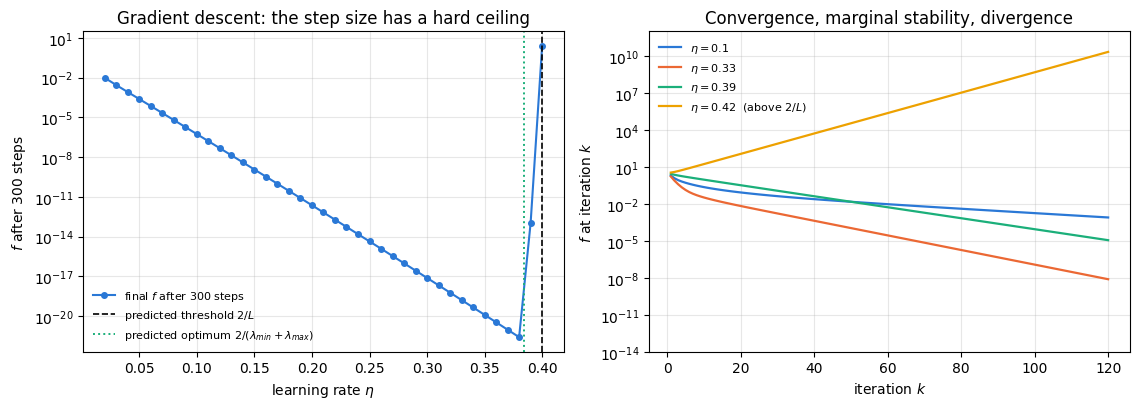

In [5]:
# ==============================================================================
# STEP 2: gradient descent, and the measured stability threshold on the quadratic
# ==============================================================================
def opt_gd(lr):
    """Gradient descent, Eq. (3).  State: nothing.  `lr` may be a traced scalar (so it can be vmapped over)."""
    return (lambda theta: jnp.zeros(())), (lambda theta, st, g, k: (theta - lr * g, st))


def run_quadratic(opt, x0, n_steps):
    """Run an optimiser on the test quadratic with EXACT gradients; return the history of f(x)."""
    init_fn, update_fn = opt

    def body(carry, k):
        x, st = carry
        x, st = update_fn(x, st, gf_quad(x), k)
        return (x, st), f_quad(x)

    return lax.scan(body, (x0, init_fn(x0)), jnp.arange(1, n_steps + 1))[1]


x0_q = jnp.ones(LAMS.size)
lrs = jnp.asarray(np.linspace(0.02, 0.56, 55))
hist_lr = jax.jit(jax.vmap(lambda lr: run_quadratic(opt_gd(lr), x0_q, 300)))(lrs)
final = np.asarray(hist_lr[:, -1])
converged = np.isfinite(final) & (final < float(f_quad(x0_q)))     # the cost went DOWN over 300 steps
bad = np.where(~converged)[0]
lr_threshold = float(lrs[bad[0] - 1]) if len(bad) else float(lrs[-1])
lr_best = float(lrs[int(np.argmin(np.where(converged, final, np.inf)))])

print(f"gradient descent on the test quadratic, 300 steps from x = (1,...,1)")
print(f"  predicted stability threshold 2/L     = {2 / L_quad:.4f}")
print(f"  largest lr that still converged       = {lr_threshold:.4f}   "
      f"(grid spacing {float(lrs[1] - lrs[0]):.4f})")
print(f"  predicted optimal lr 2/(lmin+lmax)    = {2 / float(jnp.min(LAMS) + jnp.max(LAMS)):.4f}")
print(f"  measured optimal lr (lowest final f)  = {lr_best:.4f}")
print(f"  predicted contraction per step rho*   = {(kappa_quad - 1) / (kappa_quad + 1):.4f}")
h_best = np.maximum(np.asarray(hist_lr[int(np.argmin(np.where(converged, final, np.inf)))]), 1e-300)
rho_meas = float(np.exp(np.polyfit(np.arange(150, 300), np.log(h_best[150:300]), 1)[0] / 2))
print(f"  measured contraction per step         = {rho_meas:.4f}   (from the slope of log f over steps 150-300)")
rho_at_best = max(abs(1 - lr_best * float(jnp.min(LAMS))), abs(1 - lr_best * L_quad))     # Eq. (6) at the measured lr
print(f"  Eq. (6) at the measured lr: max|1 - lr*lambda| = {rho_at_best:.4f}")
assert abs(lr_threshold - 2 / L_quad) <= float(lrs[1] - lrs[0]) + 1e-12 and abs(rho_meas - rho_at_best) < 1e-3

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].semilogy(np.asarray(lrs), np.where(converged, final, np.nan), "o-", ms=4, color=PALETTE[0],
                 label="final $f$ after 300 steps")
axes[0].axvline(2 / L_quad, color="k", ls="--", lw=1.2, label=r"predicted threshold $2/L$")
axes[0].axvline(2 / float(jnp.min(LAMS) + jnp.max(LAMS)), color=PALETTE[2], ls=":", lw=1.4,
                label=r"predicted optimum $2/(\lambda_{min}+\lambda_{max})$")
axes[0].set_xlabel(r"learning rate $\eta$"); axes[0].set_ylabel(r"$f$ after 300 steps")
axes[0].set_title("Gradient descent: the step size has a hard ceiling"); axes[0].legend(fontsize=8)

for j, lr in enumerate((0.1, 0.33, 0.39, 0.42)):
    h = np.asarray(run_quadratic(opt_gd(lr), x0_q, 120))
    axes[1].semilogy(np.arange(1, 121), np.abs(h), "-", lw=1.6, color=PALETTE[j],
                     label=f"$\\eta={lr}$" + ("  (above $2/L$)" if lr > 2 / L_quad else ""))
axes[1].set_xlabel("iteration $k$"); axes[1].set_ylabel("$f$ at iteration $k$")
axes[1].set_ylim(1e-14, 1e12)
axes[1].set_title("Convergence, marginal stability, divergence"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

All three predictions are confirmed. The largest learning rate on the $0.01$ grid for which the cost fell over
300 steps is $0.40=2/L$ itself. That grid point is the marginal case of Eq. (5): the $\lambda=5$ component keeps its
amplitude ($\lvert1-0.4\cdot5\rvert=1$), so $f$ does not go to zero but settles at $\tfrac12\cdot5\cdot1^2=2.5$, below the
starting value $f(\mathbf x_0)=4.35$; the criterion "the cost fell" therefore counts it as converged although it is not
(Exercise 1 makes this precise). The run at $\eta=0.42$ in the right panel grows without bound. The best learning rate
of the sweep, $0.38$, is the grid point next to the predicted $2/(\lambda_{\min}+\lambda_{\max})=0.3846$. At
$\eta=0.38$ Eq. (6) gives the contraction factor $\max(\lvert1-0.38\cdot0.2\rvert,\lvert1-0.38\cdot5\rvert)=0.9240$, and
the slope of $\log f$ over steps 150 to 300 gives $0.9240$; the optimum of Eq. (6), reached at $\eta_\star$ exactly, is
$\rho_\star=(\kappa-1)/(\kappa+1)=0.9231$.

### 4.3 The same threshold on a circuit landscape

Nothing in the derivation was specific to a quadratic: near enough to a minimum, every smooth cost *is* a quadratic. We
test that on a real variational problem — preparing a GHZ state — by finding a minimum, diagonalising the Hessian there,
and checking that $2/\lambda_{\max}$ predicts where gradient descent starts to diverge.

GHZ preparation, N=4, L=3, n=32 parameters
  infidelity at the minimum found by Adam: 9.330e-06


  gradient norm there:                     6.827e-03


  Hessian eigenvalues: min -0.0013, max +3.4646, 22 of 32 above 1e-6
  predicted stability threshold 2/lambda_max = 0.5773


  measured: the smallest lr on the grid for which the cost did NOT fall over 200 steps = 0.5917
            (grid spacing 0.0433)


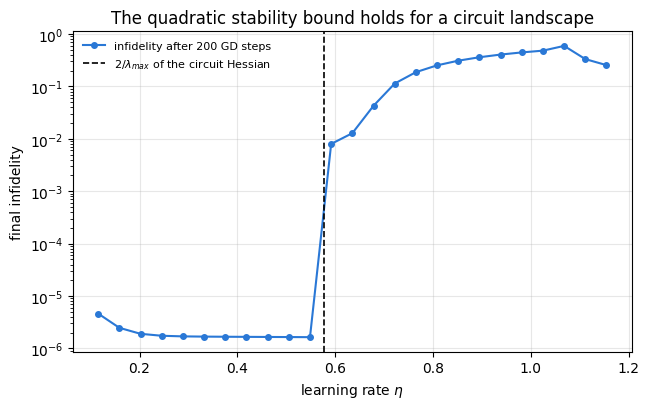

In [6]:
# ==============================================================================
# STEP 3: the curvature of a real circuit landscape, and its stability threshold
# ==============================================================================
N_GHZ, L_GHZ = 4, 3
N_PAR = hea_num_params(N_GHZ, L_GHZ)
target_ghz = ghz_state(N_GHZ)


def infidelity(theta):
    """C(theta) = 1 - |<GHZ|psi(theta)>|^2 -- the state-preparation cost of notebook 40, Eq. (8)."""
    return 1.0 - fidelity_pure(target_ghz, hardware_efficient_ansatz(theta, N_GHZ, L_GHZ))


cost_ghz = jax.jit(infidelity)
grad_ghz = jax.jit(jax.grad(infidelity))

# find a minimum with the engine's Adam, then look at the curvature there
theta = jax.random.uniform(jax.random.PRNGKey(0), (N_PAR,), minval=-jnp.pi, maxval=jnp.pi)
st = adam_init(theta)
for k in range(600):
    theta, st = adam_update(theta, grad_ghz(theta), st, lr=0.05)
print(f"GHZ preparation, N={N_GHZ}, L={L_GHZ}, n={N_PAR} parameters")
print(f"  infidelity at the minimum found by Adam: {float(cost_ghz(theta)):.3e}")
print(f"  gradient norm there:                     {float(jnp.linalg.norm(grad_ghz(theta))):.3e}")

Hess = jax.hessian(infidelity)(theta)
ev = np.sort(np.asarray(jnp.linalg.eigvalsh(Hess)))
L_circ = float(ev[-1])
print(f"  Hessian eigenvalues: min {ev[0]:+.4f}, max {ev[-1]:+.4f}, "
      f"{int(np.sum(ev > 1e-6))} of {N_PAR} above 1e-6")
print(f"  predicted stability threshold 2/lambda_max = {2 / L_circ:.4f}")

# gradient descent started NEAR that minimum, for a range of learning rates
theta_near = theta + 0.02 * jax.random.normal(jax.random.PRNGKey(1), (N_PAR,))


def run_gd_circuit(lr, n_steps=200):
    def body(th, _):
        return th - lr * grad_ghz(th), cost_ghz(th)
    return lax.scan(body, theta_near, None, length=n_steps)[1]


lrs_c = jnp.asarray(np.linspace(0.2 * 2 / L_circ, 2.0 * 2 / L_circ, 25))      # grid centred on the prediction
hc = np.asarray(jax.jit(jax.vmap(run_gd_circuit))(lrs_c))
grew = ~(np.isfinite(hc[:, -1])) | (hc[:, -1] > hc[:, 0])
first_bad = float(lrs_c[int(np.argmax(grew))]) if grew.any() else float("nan")
print(f"  measured: the smallest lr on the grid for which the cost did NOT fall over 200 steps = {first_bad:.4f}")
print(f"            (grid spacing {float(lrs_c[1] - lrs_c[0]):.4f})")
assert 0 < first_bad - 2 / L_circ <= float(lrs_c[1] - lrs_c[0])           # the first failing grid point brackets 2/L

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.semilogy(np.asarray(lrs_c), np.maximum(hc[:, -1], 1e-18), "o-", ms=4, color=PALETTE[0],
            label="infidelity after 200 GD steps")
ax.axvline(2 / L_circ, color="k", ls="--", lw=1.2, label=r"$2/\lambda_{max}$ of the circuit Hessian")
ax.set_xlabel(r"learning rate $\eta$"); ax.set_ylabel("final infidelity")
ax.set_title("The quadratic stability bound holds for a circuit landscape")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

Adam brings the infidelity to $9\cdot10^{-6}$ with a residual gradient norm of $7\cdot10^{-3}$: close to a minimum, but
not exactly at one, which is why the smallest Hessian eigenvalue comes out slightly negative, at $-1.3\cdot10^{-3}$,
rather than at zero. The largest is $3.46$, and only $22$ of the $32$ eigenvalues exceed $10^{-6}$: **the landscape is
flat in about ten directions** around this minimum. Counting parameters explains only two of them: a normalised
four-qubit state up to a global phase has $2\cdot2^4-2=30$ real degrees of freedom, so 32 angles have at least two
redundant combinations, and at a random point the metric of Section 9 indeed has rank 30. The other flat directions
appear because the GHZ state is a special point of the ansatz, where the map from angles to states loses rank;
Section 9 shows that at an exact minimum the Hessian equals twice the metric tensor, and measures that rank.

The prediction that matters is the threshold. Gradient descent restarted near that point converges for learning rates
below $2/\lambda_{\max}=0.577$ and stops converging above it; on a grid of spacing $0.043$ the first failing grid point
is $0.592$, and the last converging one is $0.548$, so the measured threshold lies between the two grid points that
bracket the prediction. Near a minimum the quadratic model of Section 4.2 describes the circuit landscape
quantitatively.

> **Numerical practice.** The flat directions matter. A Hessian with a null space means the minimum is a *manifold*, not
> a point: many different angle vectors prepare the same state. Optimisers do not need to break that degeneracy, but any
> method that tries to *invert* a curvature matrix must regularise it — as the natural gradient of Section 9 does.

## 5. Heavy-ball momentum

### 5.1 The update equation

Gradient descent treats each step independently. The **heavy-ball** method (Polyak) gives the iterate inertia:

$$\boxed{\;\mathbf v_{k+1}=\beta\,\mathbf v_k+\mathbf g_k,\qquad
  \boldsymbol\theta_{k+1}=\boldsymbol\theta_k-\eta\,\mathbf v_{k+1}\;}\tag{7}$$

with $\beta\in[0,1)$. Unrolling, $\mathbf v_{k+1}=\sum_{j\le k}\beta^{k-j}\mathbf g_j$: the step is an exponentially
weighted average of all past gradients, with effective averaging window $1/(1-\beta)$. Two consequences:

* along a direction where the gradient keeps the same sign, the terms add up and the effective step grows by up to
  $1/(1-\beta)$ — progress along a long flat valley is accelerated;
* along a direction where the gradient oscillates in sign (the high-curvature directions responsible for the
  instability of Section 4.2), consecutive terms cancel — the oscillation is damped.

### 5.2 Why it converges faster

On the quadratic of Eq. (2) each component again decouples, but the recursion is now second order. With
$x^{(k)}$ and $v^{(k)}$ the component along an eigendirection of curvature $\lambda$,

$$\begin{pmatrix}v^{(k+1)}\\x^{(k+1)}\end{pmatrix}
  =\underbrace{\begin{pmatrix}\beta&\lambda\\-\eta\beta&1-\eta\lambda\end{pmatrix}}_{\mathbf T(\lambda)}
  \begin{pmatrix}v^{(k)}\\x^{(k)}\end{pmatrix}. \tag{8}$$

Convergence requires the spectral radius of $\mathbf T(\lambda)$ to be below $1$ for every $\lambda$. Its characteristic
polynomial is $\mu^2-(1+\beta-\eta\lambda)\mu+\beta=0$, so the product of the two roots is $\beta$: when the roots are
complex (which happens for an intermediate range of $\eta\lambda$) they both have modulus exactly $\sqrt\beta$,
*independently of $\lambda$*. Choosing $\eta,\beta$ so that this happens for **every** curvature in
$[\lambda_{\min},\lambda_{\max}]$ gives the classical optimum

$$\beta_\star=\Bigl(\frac{\sqrt\kappa-1}{\sqrt\kappa+1}\Bigr)^{2},\qquad
  \eta_\star=\Bigl(\frac{2}{\sqrt{\lambda_{\min}}+\sqrt{\lambda_{\max}}}\Bigr)^{2},\qquad
  \rho_\star=\frac{\sqrt\kappa-1}{\sqrt\kappa+1}\approx1-\frac{2}{\sqrt\kappa}. \tag{9}$$

Comparing with Eq. (6): the number of iterations per digit drops from $O(\kappa)$ to $O(\sqrt\kappa)$. For
$\kappa=100$ that is a factor of ten. We measure the scaling against $\kappa$ directly.

iterations to reach f < 1e-06, each method with its own optimal parameters
   kappa |  GD measured  GD predicted |  HB measured  HB predicted |   GD/HB  sqrt(kappa)


       4 |           15            14 |            9             7 |     1.7          2.0
      16 |           64            64 |           23            17 |     2.8          4.0
      64 |          277           277 |           53            36 |     5.2          8.0


     256 |         1195          1195 |          118            77 |    10.1         16.0
    1024 |         5135          5134 |          260           164 |    19.8         32.0


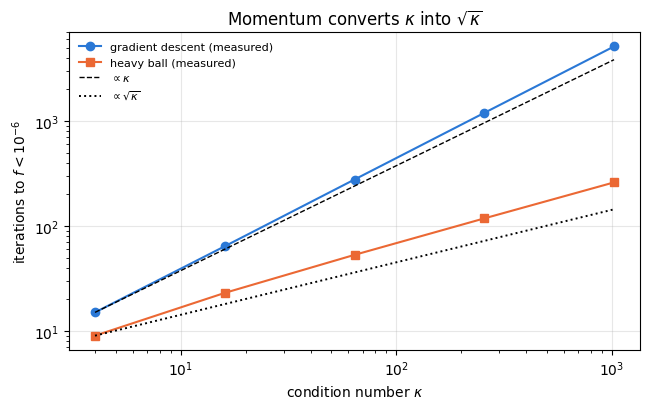

In [7]:
# ==============================================================================
# STEP 4: heavy-ball momentum, and the sqrt(kappa) scaling measured
# ==============================================================================
def opt_momentum(lr, beta):
    """Heavy-ball momentum, Eq. (7).  State: the velocity vector v."""
    return (lambda theta: jnp.zeros_like(theta)), \
           (lambda theta, v, g, k: (theta - lr * (beta * v + g), beta * v + g))


TARGET_Q, N_STEPS_Q = 1e-6, 9000
print(f"iterations to reach f < {TARGET_Q:g}, each method with its own optimal parameters")
print(f"{'kappa':>8s} | {'GD measured':>12s} {'GD predicted':>13s} | {'HB measured':>12s} {'HB predicted':>13s}"
      f" | {'GD/HB':>7s} {'sqrt(kappa)':>12s}")
kappas = (4.0, 16.0, 64.0, 256.0, 1024.0)
it_gd, it_hb = [], []
for kap in kappas:
    lam = jnp.asarray(np.geomspace(1.0, kap, 8), dtype=RDTYPE)
    f_k, gf_k = quadratic(lam)
    lmin, lmax = float(jnp.min(lam)), float(jnp.max(lam))
    lr_gd = 2.0 / (lmin + lmax)                                   # Eq. (6)
    beta_hb = ((np.sqrt(kap) - 1) / (np.sqrt(kap) + 1)) ** 2      # Eq. (9)
    lr_hb = (2.0 / (np.sqrt(lmin) + np.sqrt(lmax))) ** 2
    x_init = jnp.ones(lam.size)
    f0 = float(f_k(x_init))

    def run(opt, n=N_STEPS_Q):
        init_fn, update_fn = opt

        def body(carry, k):
            x, st = carry
            x, st = update_fn(x, st, gf_k(x), k)
            return (x, st), f_k(x)
        return np.asarray(lax.scan(body, (x_init, init_fn(x_init)), jnp.arange(1, n + 1))[1])

    h_gd = run(opt_gd(lr_gd))
    h_hb = run(opt_momentum(lr_hb, beta_hb))
    n_gd = int(iterations_to(h_gd[None, :], TARGET_Q)[0])
    n_hb = int(iterations_to(h_hb[None, :], TARGET_Q)[0])
    it_gd.append(n_gd); it_hb.append(n_hb)
    # GD: at large k only the two extreme components survive, both with |1 - eta lam| = rho, so
    #     f_k -> 0.5 (lmin + lmax) rho^{2k}  and the target is reached at k = ln(0.5 (lmin+lmax)/target) / (-2 ln rho)
    # HB: the same estimate with f0 in place of the prefactor (Eq. (9) gives only the asymptotic rate)
    p_gd = np.log(0.5 * (lmin + lmax) / TARGET_Q) / (-2 * np.log((kap - 1) / (kap + 1)))
    p_hb = np.log(f0 / TARGET_Q) / (-2 * np.log((np.sqrt(kap) - 1) / (np.sqrt(kap) + 1)))
    print(f"{kap:8.0f} | {n_gd:12d} {p_gd:13.0f} | {n_hb:12d} {p_hb:13.0f}"
          f" | {n_gd / n_hb:7.1f} {np.sqrt(kap):12.1f}")

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.loglog(kappas, it_gd, MARKERS[0] + "-", ms=6, color=PALETTE[0], label="gradient descent (measured)")
ax.loglog(kappas, it_hb, MARKERS[1] + "-", ms=6, color=PALETTE[1], label="heavy ball (measured)")
ax.loglog(kappas, np.array(it_gd)[0] * np.array(kappas) / kappas[0], "k--", lw=1, label=r"$\propto\kappa$")
ax.loglog(kappas, np.array(it_hb)[0] * np.sqrt(np.array(kappas) / kappas[0]), "k:", lw=1.4,
          label=r"$\propto\sqrt{\kappa}$")
ax.set_xlabel(r"condition number $\kappa$"); ax.set_ylabel(r"iterations to $f<10^{-6}$")
ax.set_title("Momentum converts $\\kappa$ into $\\sqrt{\\kappa}$")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

The gradient-descent column agrees with the prediction to within one iteration: $15$, $64$, $277$, $1195$, $5135$
measured against $14$, $64$, $277$, $1195$, $5134$, over two and a half decades of condition number. The prediction uses
the fact that at large $k$ only the two extreme components survive, both with $\lvert1-\eta_\star\lambda\rvert=\rho_\star$,
so $f_k\to\tfrac12(\lambda_{\min}+\lambda_{\max})\rho_\star^{2k}$.

The heavy-ball column sits above its prediction by a factor that grows with $\kappa$, from $1.3$ to $1.6$: $9$, $23$,
$53$, $118$, $260$ against $7$, $17$, $36$, $77$, $164$. The reason is a property of the optimal parameters of Eq. (9).
They are chosen so that the discriminant $(1+\beta-\eta\lambda)^2-4\beta$ of the characteristic polynomial vanishes at
$\lambda_{\min}$ and at $\lambda_{\max}$. There the two roots coincide, $\mathbf T(\lambda)$ cannot be diagonalised, and the
component decays as $(a+bk)\rho_\star^k$ instead of $\rho_\star^k$ (a critically damped oscillator). The extra factor
$k$ costs about $\ln k/\ln(1/\rho_\star)\approx\tfrac12\sqrt\kappa\ln k$ additional iterations, an amount that grows with
$\kappa$; the prediction column, which uses the rate alone, does not contain it.

The ratio in the last two columns grows as $\sqrt\kappa$ to within the same correction: the measured ratios $1.7$, $2.8$,
$5.2$, $10.1$, $19.8$ are $0.83$, $0.70$, $0.65$, $0.63$, $0.62$ times $\sqrt\kappa=2,4,8,16,32$, a prefactor that drifts
down slowly because of the $\ln k$ term. At $\kappa=1024$ that is the difference between five thousand iterations and
two hundred and sixty, and on hardware each iteration costs thousands of circuit executions. Both measured curves are
also slightly steeper than the reference power laws because the starting value $f(\mathbf x_0)=\tfrac12\sum_i\lambda_i$
grows with $\kappa$.

> **Common pitfall.** Equation (9) needs $\kappa$, which nobody knows for a circuit landscape. In practice $\beta$ is
> fixed at $0.9$ (an averaging window of ten steps) and $\eta$ is tuned. Section 11 does exactly that, by measurement.

## 6. Adam

### 6.1 The update equation

Adam (Kingma and Ba, ICLR 2015) combines momentum with a **per-parameter** step size inferred from the recent magnitude of
each gradient component:

$$\begin{aligned}
\mathbf m_k&=\beta_1\mathbf m_{k-1}+(1-\beta_1)\,\mathbf g_k &&\text{(first moment: a running mean)}\\
\mathbf v_k&=\beta_2\mathbf v_{k-1}+(1-\beta_2)\,\mathbf g_k^{\odot2} &&\text{(second moment: a running mean square)}\\
\hat{\mathbf m}_k&=\frac{\mathbf m_k}{1-\beta_1^{\,k}},\qquad
\hat{\mathbf v}_k=\frac{\mathbf v_k}{1-\beta_2^{\,k}} &&\text{(bias correction, derived below)}\\
\boldsymbol\theta_{k+1}&=\boldsymbol\theta_k-\eta\,
  \frac{\hat{\mathbf m}_k}{\sqrt{\hat{\mathbf v}_k}+\epsilon} . &&
\end{aligned}\tag{10}$$

The division by $\sqrt{\hat v}$ makes the update **scale invariant** (up to the tiny $\epsilon$): multiplying the cost by a
constant multiplies both $\hat m$ and $\sqrt{\hat v}$ by that constant, and the step is unchanged. Components with persistently large gradients
are therefore damped and flat directions are amplified, which is a crude diagonal substitute for the curvature
information that the Newton step would use.

### 6.2 The Adam bias correction

Both moments start at zero, which biases them towards zero in the early iterations. Unroll the first recursion with
$\mathbf m_0=0$:

$$\mathbf m_k=(1-\beta_1)\sum_{j=1}^{k}\beta_1^{\,k-j}\,\mathbf g_j .$$

If the gradients were stationary with mean $\bar{\mathbf g}$, the expectation would be

$$\mathbb E[\mathbf m_k]=(1-\beta_1)\,\bar{\mathbf g}\sum_{j=1}^{k}\beta_1^{\,k-j}
 =(1-\beta_1)\,\bar{\mathbf g}\,\frac{1-\beta_1^{\,k}}{1-\beta_1}
 =\bar{\mathbf g}\,\bigl(1-\beta_1^{\,k}\bigr), \tag{11}$$

using the geometric sum $\sum_{j=1}^{k}\beta^{k-j}=(1-\beta^k)/(1-\beta)$. The running mean therefore under-estimates
the true mean by exactly the factor $1-\beta_1^{\,k}$, and dividing by it removes the bias. The same computation with
$\mathbf g_j^{\odot2}$ gives the $1-\beta_2^{\,k}$ of the second moment.

The two corrections act in opposite directions on the step. At $k=1$, $\mathbf m_1=(1-\beta_1)\mathbf g_1$ and
$\mathbf v_1=(1-\beta_2)\mathbf g_1^{\odot2}$, so without any correction each component moves by
$\eta\,(1-\beta_1)/\sqrt{1-\beta_2}=\eta\cdot0.1/\sqrt{0.001}=3.16\,\eta$, whatever the size of the gradient; with
both corrections it moves by exactly $\eta$. Correcting only the second moment would give $0.1\,\eta$, and correcting
only the first $\sqrt{1000}\,\eta\approx32\,\eta$. In general the uncorrected step is the corrected one multiplied by
$(1-\beta_1^{\,k})/\sqrt{1-\beta_2^{\,k}}$, which the cell below tabulates.

### 6.3 What the step-size bound of Eq. (5) does not say about Adam

For gradient descent the step is $\eta\mathbf g$, so it grows with the gradient, and a curvature above $2/\eta$ amplifies
the error at every step. Adam's step per component is $\eta\,\hat m_k/(\sqrt{\hat v_k}+\epsilon)$. With bias correction,
$\hat m_k=\sum_jw_jg_j$ and $\hat v_k=\sum_ju_jg_j^2$ are weighted averages (weights
$w_j=(1-\beta_1)\beta_1^{k-j}/(1-\beta_1^k)$ and $u_j=(1-\beta_2)\beta_2^{k-j}/(1-\beta_2^k)$, each summing to one), and
the Cauchy–Schwarz inequality gives

$$\frac{\lvert\hat m_k\rvert}{\sqrt{\hat v_k}}\le\Bigl(\sum_j\frac{w_j^2}{u_j}\Bigr)^{1/2}
  \;\xrightarrow{k\to\infty}\;\frac{1-\beta_1}{\sqrt{(1-\beta_2)(1-\beta_1^2/\beta_2)}}\approx7.3 ,$$

for the default $\beta_1=0.9$, $\beta_2=0.999$, and the ratio is exactly $1$ when the gradient component is constant. Each
component therefore moves by at most a few $\eta$ per step, whatever the curvature: Adam cannot diverge geometrically,
and there is no threshold like Eq. (5). The step shrinks only when the current gradient becomes small compared with
the root-mean-square gradient remembered by $\hat v$ over the last $\sim1/(1-\beta_2)$ iterations. The second part of the
cell below measures this on the test quadratic of Eq. (2), with learning rates far above its gradient-descent threshold
$2/L=0.4$. For heavy-ball momentum Section 11 derives the corresponding bound, $\eta<2(1+\beta)/\lambda_{\max}$.

In [8]:
# ==============================================================================
# STEP 5: Adam from scratch, validated against the engine implementation
# ==============================================================================
def opt_adam(lr, b1=0.9, b2=0.999, eps=1e-8):
    """Adam, Eq. (10), written from the update equations.  State: (m, v); the counter k comes from the scan."""
    def init(theta):
        return (jnp.zeros_like(theta), jnp.zeros_like(theta))

    def update(theta, state, g, k):
        m, v = state
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g ** 2
        m_hat = m / (1 - b1 ** k)                       # Eq. (11)
        v_hat = v / (1 - b2 ** k)
        return theta - lr * m_hat / (jnp.sqrt(v_hat) + eps), (m, v)

    return init, update


# --- CHECKPOINT: reproduce the engine's adam_update step by step ---------------------------
theta_a = jax.random.uniform(jax.random.PRNGKey(4), (N_PAR,), minval=-1.0, maxval=1.0)
init_a, upd_a = opt_adam(0.05)
th_ours, st_ours = theta_a, init_a(theta_a)
th_eng, st_eng = theta_a, adam_init(theta_a)
for k in range(1, 26):
    g = grad_ghz(th_ours)
    th_ours, st_ours = upd_a(th_ours, st_ours, g, k)
    th_eng, st_eng = adam_update(th_eng, grad_ghz(th_eng), st_eng, lr=0.05)
print(f"25 Adam steps, from-scratch vs engine: max |theta difference| = {max_abs(th_ours - th_eng):.2e}")
assert max_abs(th_ours - th_eng) < TOL
# wrong control: the same comparison with the counter off by one (bias correction applied for k+1) must fail
th_w, st_w = theta_a, init_a(theta_a)
for k in range(1, 26):
    th_w, st_w = upd_a(th_w, st_w, grad_ghz(th_w), k + 1)
print(f"control, counter off by one:                    max |theta difference| = {max_abs(th_w - th_eng):.2e}")
assert max_abs(th_w - th_eng) > 1e-3

# --- the bias correction, seen ------------------------------------------------------------
print("\nbias-correction factors of Eq. (11):")
print(f"{'k':>5s} {'1 - b1^k':>12s} {'1 - b2^k':>12s} {'step without / with correction':>32s}")
for k in (1, 2, 5, 20, 100, 1000, 3000):
    c1, c2 = 1 - 0.9 ** k, 1 - 0.999 ** k
    print(f"{k:5d} {c1:12.5f} {c2:12.6f} {c1 / np.sqrt(c2):32.4f}")
k_all = np.arange(1, 10001)
amp = (1 - 0.9 ** k_all) / np.sqrt(1 - 0.999 ** k_all)
print(f"largest ratio {amp.max():.3f} at k = {k_all[np.argmax(amp)]}")

# --- Section 6.3: Adam on the test quadratic, far above the gradient-descent threshold 2/L = 0.4 ----------------
print(f"\nAdam on the test quadratic of Eq. (2) (gradient descent diverges for lr > {2 / L_quad:.1f})")
print(f"{'lr':>6s} {'f after 100':>13s} {'f after 1000':>13s} {'f after 3000':>13s} {'largest f seen':>15s}")
for lr in (0.01, 0.05, 0.4, 1.0, 3.0):
    h = np.asarray(run_quadratic(opt_adam(lr), x0_q, 3000))
    print(f"{lr:6.2f} {h[99]:13.2e} {h[999]:13.2e} {h[-1]:13.2e} {h.max():15.2e}")

25 Adam steps, from-scratch vs engine: max |theta difference| = 0.00e+00
control, counter off by one:                    max |theta difference| = 6.86e-02

bias-correction factors of Eq. (11):
    k     1 - b1^k     1 - b2^k   step without / with correction
    1      0.10000     0.001000                           3.1623
    2      0.19000     0.001999                           4.2496
    5      0.40951     0.004990                           5.7971
   20      0.87842     0.019811                           6.2409
  100      0.99997     0.095208                           3.2408
 1000      1.00000     0.632305                           1.2576
 3000      1.00000     0.950288                           1.0258
largest ratio 6.569 at k = 12

Adam on the test quadratic of Eq. (2) (gradient descent diverges for lr > 0.4)
    lr   f after 100  f after 1000  f after 3000  largest f seen
  0.01      2.19e-01      1.43e-41     6.88e-132        4.26e+00
  0.05      7.72e-05      1.31e-45     7.73e-13

  0.40      3.00e-05      1.06e-45     2.24e-137        1.57e+00
  1.00      9.72e-06      1.01e-48      1.88e-39        2.41e+00
  3.00      3.70e-04      1.10e-44      4.71e-26        1.74e+01


Our implementation reproduces the engine's `adam_update` bit for bit over 25 steps, so the two can be used
interchangeably. The comparison is sensitive: shifting the iteration counter of the bias correction by one step moves
the angles by $7\cdot10^{-2}$ after 25 steps. The table shows what the correction is worth. Without it the update would be multiplied by
$(1-\beta_1^k)/\sqrt{1-\beta_2^k}$: $3.16$ at $k=1$, a maximum of $6.57$ at $k=12$, still $3.24$ at $k=100$ and $1.26$ at
$k=1000$. The uncorrected steps are *larger* than the corrected ones, because the second moment is biased much more
strongly than the first and a small $m$ is divided by an even smaller $\sqrt v$. The ratio approaches $1$ only after a
few thousand iterations, longer than any run in this notebook.

The second table is the measurement promised in Section 6.3. On the test quadratic, gradient descent diverges for
$\eta>0.4$; Adam does not diverge at $\eta=1$ or $\eta=3$, and its largest cost along the run stays of the order of
the starting value $4.35$ (at $\eta=3$ it overshoots once, to the value in the last column, and then recovers). On this
deterministic problem Adam even converges at those step sizes: as the gradient decays, $\sqrt{\hat v}$ still remembers
the larger gradients of the last $1/(1-\beta_2)=1000$ iterations, so $\lvert\hat m\rvert/\sqrt{\hat v}$ falls below one and
the step shrinks. What the step size controls for Adam is the length of the early steps and the size of the
oscillations; it sets no sharp divergence threshold.

## 7. SPSA and Spall's gain sequences

SPSA replaces $\nabla C$ by the two-evaluation estimate of notebook 40,

$$\hat g_k=\frac{C(\boldsymbol\theta_k+c_k\boldsymbol\Delta_k)-C(\boldsymbol\theta_k-c_k\boldsymbol\Delta_k)}
  {2c_k}\,\boldsymbol\Delta_k^{\odot-1}, \tag{12}$$

and steps with $\boldsymbol\theta_{k+1}=\boldsymbol\theta_k-a_k\hat g_k$. Because $\hat g_k$ is random, a **constant**
step size cannot converge: the iterate would keep jittering with an amplitude set by $a\,\mathrm{std}(\hat g)$. Both
gains must therefore decay, and stochastic-approximation theory (Robbins and Monro for root finding from noisy
measurements, here of the gradient; extended by Spall to the estimator of Eq. (12)) says how.

### 7.1 The three conditions

For $\boldsymbol\theta_k$ to converge almost surely to a stationary point one needs

$$\text{(i)}\ a_k\to0,\qquad
  \text{(ii)}\ \sum_{k}a_k=\infty,\qquad
  \text{(iii)}\ \sum_{k}\Bigl(\frac{a_k}{c_k}\Bigr)^{2}<\infty ,\qquad
  \text{(iv)}\ c_k\to0 . \tag{13}$$

The reading is physical. (i) and (iv): the steps and the probe radius must shrink, otherwise the iterate cannot settle
and the $O(c^2)$ bias of the estimator never vanishes. (ii): the steps must not shrink *so* fast that their total length
is finite — otherwise the iterate can stall before reaching the minimum. (iii): $\mathrm{Var}(\hat g_k)$ grows like
$c_k^{-2}$ once the cost is noisy (notebook 40, Eq. (29)), so $a_k^2/c_k^2$ is the variance actually injected into the
iterate at step $k$, and the total injected noise must be finite.

### 7.2 Where the exponents come from

Spall's standard choice is the power law

$$a_k=\frac{a}{(k+A)^{\alpha}},\qquad c_k=\frac{c}{k^{\gamma}} . \tag{14}$$

Substituting into Eq. (13): (ii) requires $\alpha\le1$; (iii) requires $\sum k^{-2(\alpha-\gamma)}<\infty$, i.e.

$$\alpha-\gamma>\tfrac12 . \tag{15}$$

Eq. (15) alone would allow $\gamma\to0$ and $\alpha$ just above $\tfrac12$. Spall's asymptotic-normality theorem for SPSA,
which controls how the error is distributed around the minimum at large $k$, adds two more conditions,
$\alpha-2\gamma>0$ and $3\gamma-\alpha/2\ge0$, i.e. $\gamma\ge\alpha/6$. Combining $\gamma\ge\alpha/6$ with Eq. (15) gives
$\alpha-\alpha/6>\tfrac12$, i.e. $\alpha>0.6$ and $\gamma\ge0.1$. Two regimes are in use (Spall, 1998).

* **Asymptotically optimal**: $\alpha=1$, $\gamma=1/6$. These maximise the rate at which the mean squared error decays
  as $k\to\infty$.
* **Practically effective**: $\alpha=0.602$, $\gamma=0.101$, which Spall describes as effectively the lowest values
  allowed by the theory: $0.602-0.101=0.501>\tfrac12$ and $0.101\ge0.602/6=0.1003$, each with almost nothing to spare.
  Small exponents mean the gains decay slowly, so the algorithm keeps taking useful steps for hundreds of iterations
  instead of freezing after twenty. A variational run is stopped after a few hundred iterations and never reaches the
  asymptotic regime, so this is the choice used below.

The **stability constant** $A$ shifts the schedule: $a_1=a/(1+A)^\alpha$, so a large $A$ prevents an enormous first step
when the initial gradient estimate happens to be large. Spall's guideline is $A$ of about 10% (or less) of the planned
number of iterations; we use $A=30$ for runs of 200 to 400 iterations.

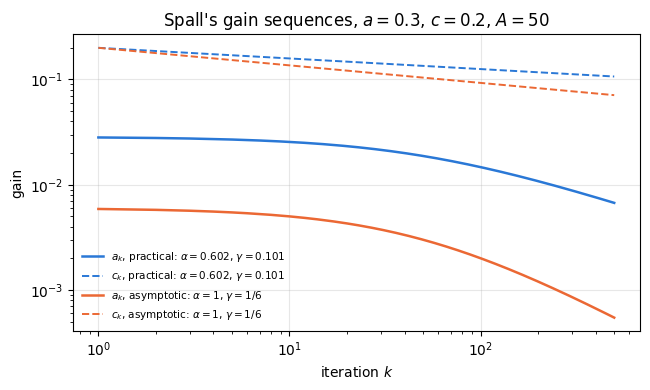

cumulative step length sum_k a_k and injected noise sum_k (a_k/c_k)^2 after 500 iterations:
  alpha   gamma  alpha-gamma    sum a_k    sum (a_k/c_k)^2  Eq. (15) satisfied
  0.602   0.101        0.501       5.70             4.7289                True
  1.000   0.167        0.833       0.72             0.1506                True
  0.400   0.101        0.299      16.79            39.8439               False
  0.602   0.400        0.202       5.70            93.1314               False


In [9]:
# ==============================================================================
# STEP 6: SPSA as a gradient rule with schedule c_k, plus a step size with schedule a_k
# ==============================================================================
def grad_spsa_exact(cost, c=0.2, gamma=0.101):
    """SPSA gradient rule, Eq. (12), with the probe radius c_k = c / k^gamma and an EXACT cost function.

    JAX   the Rademacher draw uses the key supplied by the training loop, so runs are reproducible and vmappable.
    COST  2 cost evaluations per call, whatever the number of parameters.
    """
    def rule(theta, key, k):
        c_k = c / k ** gamma
        delta = jax.random.rademacher(key, theta.shape).astype(theta.dtype)
        return (cost(theta + c_k * delta) - cost(theta - c_k * delta)) / (2 * c_k) * delta
    return rule


def opt_spsa_step(a, A, alpha=0.602):
    """Plain descent with Spall's decaying gain a_k = a/(k+A)^alpha, Eq. (14)."""
    return (lambda theta: jnp.zeros(())), \
           (lambda theta, st, g, k: (theta - a / (k + A) ** alpha * g, st))


def grad_exact(cost):
    """Exact gradient rule: reverse-mode AD, ignoring the key and the counter."""
    gfn = jax.grad(cost)
    return lambda theta, key, k: gfn(theta)


ks = np.arange(1, 501)
fig, ax = plt.subplots(figsize=(6.6, 4.0))
for j, (al, ga, lab) in enumerate(((0.602, 0.101, r"practical: $\alpha=0.602$, $\gamma=0.101$"),
                                   (1.0, 1 / 6, r"asymptotic: $\alpha=1$, $\gamma=1/6$"))):
    ax.loglog(ks, 0.3 / (ks + 50) ** al, "-", color=PALETTE[j], lw=1.8, label=f"$a_k$, {lab}")
    ax.loglog(ks, 0.2 / ks ** ga, "--", color=PALETTE[j], lw=1.4, label=f"$c_k$, {lab}")
ax.set_xlabel("iteration $k$"); ax.set_ylabel("gain")
ax.set_title(r"Spall's gain sequences, $a=0.3$, $c=0.2$, $A=50$")
ax.legend(fontsize=7.5)
fig.tight_layout(); plt.show()

print("cumulative step length sum_k a_k and injected noise sum_k (a_k/c_k)^2 after 500 iterations:")
print(f"{'alpha':>7s} {'gamma':>7s} {'alpha-gamma':>12s} {'sum a_k':>10s} {'sum (a_k/c_k)^2':>18s} {'Eq. (15) satisfied':>19s}")
for al, ga in ((0.602, 0.101), (1.0, 1 / 6), (0.4, 0.101), (0.602, 0.4)):
    a_k, c_k = 0.3 / (ks + 50) ** al, 0.2 / ks ** ga
    print(f"{al:7.3f} {ga:7.3f} {al - ga:12.3f} {a_k.sum():10.2f} {np.sum((a_k / c_k) ** 2):18.4f} "
          f"{str(al - ga > 0.5):>19s}")

The table makes Eq. (15) concrete, with the partial sums after 500 iterations.

* $\alpha=0.602$, $\gamma=0.101$: total step length $5.7$ — the algorithm is still moving after 500 iterations — and
  injected noise $4.7$, a partial sum that converges.
* $\alpha=1$, $\gamma=1/6$ (the asymptotically optimal pair): total step length only $0.72$. This schedule has all but
  stopped by iteration 500; its optimality refers to $k\to\infty$, a regime a variational run never reaches.
* $\alpha=0.4$: $\alpha-\gamma=0.30$ violates Eq. (15). The step length is the largest of the four, $16.8$, and the
  injected noise is $39.8$ after 500 iterations and grows without bound, so in a noisy problem the late iterates are
  driven by the measurement noise.
* $\alpha=0.602$, $\gamma=0.4$: the condition fails again, and the injected noise is worse still at $93.1$. Here the
  step size is fine and the probe radius shrinks too fast, so the $1/c_k$ amplification of the noise outruns it.

## 8. The SPSA–Adam hybrid

SPSA's gradient estimate and Adam's update rule are independent choices: nothing in Eq. (10) requires $\mathbf g_k$ to
be exact. Feeding the SPSA estimate of Eq. (12) into Adam gives a method that

* costs 2 circuit evaluations per iteration, like SPSA;
* averages the very noisy estimate over $\sim1/(1-\beta_1)=10$ iterations through the first moment. If the estimates were
  independent with variance $\sigma^2$ and $\boldsymbol\theta$ moved little over that window, the stationary variance of
  $\mathbf m$ would be $(1-\beta_1)^2\sum_{j\ge0}\beta_1^{2j}\sigma^2=\frac{1-\beta_1}{1+\beta_1}\sigma^2=\sigma^2/19$, a
  reduction of the error of Eq. (24) of notebook 40 by a factor of about $19$ in variance;
* normalises the step by $\sqrt{\hat v}$, which removes the need to guess the scale of $a$.

The hybrid keeps Adam's *constant* $\eta$. By the argument of Section 7 it therefore cannot converge to the minimum; the
averaging lowers the jitter but does not remove it, and Sections 12 and 13 show the resulting floor.

In our framework this is `grad_spsa_exact` paired with `opt_adam`, with no new code. Whether it is better than
plain SPSA is an empirical question, and Sections 12 to 13 answer it.

## 9. The quantum natural gradient

### 9.1 The idea

Gradient descent minimises $C+\mathbf g^{\mathsf T}\boldsymbol\delta$ subject to a penalty
$\tfrac{1}{2\eta}\lVert\boldsymbol\delta\rVert^2$ — it treats the *Euclidean* distance in parameter space as the measure
of "how far we moved". But the angles are only coordinates; what matters physically is how far the **state** moved. Two
parametrisations of the same family of states give different gradients, and the difference can be large: a rotation
angle acting on a qubit that is nearly in an eigenstate of its generator changes the state hardly at all, whatever the
numerical value of $\partial C/\partial\theta$.

The natural gradient replaces the Euclidean penalty by the proper distance on the manifold of states. For pure states
that distance is the **Fubini–Study metric**, and it is defined by the fidelity between neighbouring states:

$$\bigl\lvert\langle\psi(\boldsymbol\theta)\vert\psi(\boldsymbol\theta+\boldsymbol\delta)\rangle\bigr\rvert^{2}
  =1-\sum_{ij}g_{ij}(\boldsymbol\theta)\,\delta_i\delta_j+O(\delta^3). \tag{16}$$

### 9.2 Deriving the metric

Expand $\vert\psi(\boldsymbol\theta+\boldsymbol\delta)\rangle=\vert\psi\rangle+\sum_i\delta_i\vert\partial_i\psi\rangle
+\tfrac12\sum_{ij}\delta_i\delta_j\vert\partial_i\partial_j\psi\rangle+\dots$ and abbreviate
$\langle\psi\vert\partial_i\psi\rangle\equiv w_i$. Normalisation, $\langle\psi\vert\psi\rangle=1$ for all
$\boldsymbol\theta$, differentiated once gives $w_i+\overline{w_i}=0$, i.e. $w_i$ is purely imaginary. Then

$$\langle\psi\vert\psi(\boldsymbol\theta+\boldsymbol\delta)\rangle
  =1+\sum_i\delta_iw_i+\tfrac12\sum_{ij}\delta_i\delta_j\langle\psi\vert\partial_i\partial_j\psi\rangle+O(\delta^3),$$

and, differentiating $\langle\psi\vert\partial_j\psi\rangle=w_j$ once more,
$\langle\psi\vert\partial_i\partial_j\psi\rangle=\partial_iw_j-\langle\partial_i\psi\vert\partial_j\psi\rangle$, where
$\partial_iw_j$ is purely imaginary (it is the derivative of a purely imaginary function) and so drops out of every real
part below.
Taking the squared modulus and keeping terms to second order, the first-order pieces contribute
$\lvert\sum_i\delta_iw_i\rvert^2=-\bigl(\sum_i\delta_iw_i\bigr)^2$ (the $w_i$ are imaginary) and the second-order pieces
contribute $2\,\mathrm{Re}\,\tfrac12\sum\delta_i\delta_j\langle\psi\vert\partial_i\partial_j\psi\rangle$. Collecting,

$$\bigl\lvert\langle\psi\vert\psi(\boldsymbol\theta+\boldsymbol\delta)\rangle\bigr\rvert^{2}
  =1-\sum_{ij}\delta_i\delta_j\Bigl[\mathrm{Re}\,\langle\partial_i\psi\vert\partial_j\psi\rangle
  -\mathrm{Re}\,\bigl(\langle\partial_i\psi\vert\psi\rangle\langle\psi\vert\partial_j\psi\rangle\bigr)\Bigr]+O(\delta^3),$$

which identifies the metric of Eq. (16), the matrix $\mathbf G$ with entries

$$\boxed{\;g_{ij}=\mathrm{Re}\,\langle\partial_i\psi\vert\partial_j\psi\rangle
  -\mathrm{Re}\,\bigl(\langle\partial_i\psi\vert\psi\rangle\langle\psi\vert\partial_j\psi\rangle\bigr)\;}\tag{17}$$

The subtracted term removes the component of $\vert\partial_i\psi\rangle$ along $\vert\psi\rangle$ itself — a pure phase
change, which moves no physical state. That is why $g$ is positive *semi*-definite and generally singular: its kernel is
exactly the set of parameter directions that do nothing to the state.

### 9.3 The update

Minimising $C+\mathbf g^{\mathsf T}\boldsymbol\delta$ (here $\mathbf g=\nabla C$ is the gradient, not the metric) under
the penalty $\tfrac{1}{2\eta}\boldsymbol\delta^{\mathsf T}\mathbf G\boldsymbol\delta$ instead of the Euclidean one gives
$\mathbf G\boldsymbol\delta=-\eta\nabla C$. $\mathbf G$ is singular (Section 9.2), so we add a small ridge
$\lambda_{\mathrm{reg}}\mathbb 1$ before solving:

$$\boxed{\;\boldsymbol\theta_{k+1}=\boldsymbol\theta_k-\eta\,(\mathbf G+\lambda_{\mathrm{reg}}\mathbb 1)^{-1}\nabla C\;}\tag{18}$$

We use $\lambda_{\mathrm{reg}}=10^{-3}$. In the eigenbasis of $\mathbf G$ the step along an eigenvector with metric
eigenvalue $g$ is $\eta/(g+\lambda_{\mathrm{reg}})$ times the gradient component along it. Along an exact kernel
direction the gradient component vanishes, because $C$ depends on $\boldsymbol\theta$ only through the state; the
danger comes from near-kernel directions with small but non-zero $g$, where the amplification $\eta/g$ would be
enormous and the ridge caps it at $\eta/\lambda_{\mathrm{reg}}=10^3\eta$. For $g\gg\lambda_{\mathrm{reg}}$ the ridge has
no effect. This is the **quantum natural gradient** (Stokes *et al.*, 2020);
$\mathbf G$ is one quarter of the quantum Fisher information matrix for the pure state family (see
[29 — quantum Fisher information](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb)).

On a simulator $\mathbf G$ is one `jacfwd` away. On hardware every entry has to be estimated from its own circuits, so
the full metric costs $O(n^2)$ circuits per iteration; Section 12 counts it as one circuit per independent entry,
$n(n+1)/2$, which is a lower count. Two cheaper routes exist. Stokes *et al.* keep only the diagonal blocks that belong
to one layer of rotations: for a layer of single-qubit rotations $e^{-i\theta_aP_a/2}$ acting on the state
$\vert\psi_l\rangle$ prepared by the preceding layers, the block is the covariance matrix
$\tfrac14\bigl(\langle P_aP_b\rangle-\langle P_a\rangle\langle P_b\rangle\bigr)$ of the generators, which can be
measured on the truncated circuit with a number of measurement settings that does not grow with $n$. Gacon *et al.*
estimate the whole metric stochastically, at constant cost, in the spirit of SPSA. We use the exact metric, because
the point here is to see what the exact method buys; Exercise 6 measures what the block-diagonal approximation loses.

In [10]:
# ==============================================================================
# STEP 7: the Fubini-Study metric and the natural-gradient rule
# ==============================================================================
def fubini_study_metric(state_fn, theta):
    """Metric tensor of Eq. (17) for a pure-state family theta -> |psi(theta)>.

    MATH   g_ij = Re[ (J^dag J)_ij ] - Re[ u_i conj(u_j) ],   J[a,i] = d psi_a / d theta_i,  u = J^dag psi
    IMPLEMENTATION  `jax.jacfwd` builds the (2^N, n) Jacobian with n forward-mode passes (one per parameter);
                    `jax.jacrev` would need one reverse pass per REAL output component, 2 * 2^N of them.  Forward
                    mode is the cheaper choice when n < 2 * 2^N: n = 32 vs 32 for N = 4, L = 3 (a tie) and
                    n = 48 vs 128 for N = 6, L = 3.
    COST   n circuit passes + O(n^2 2^N) for the product J^dag J.
    """
    psi = state_fn(theta).reshape(-1)
    J = jax.jacfwd(lambda t: state_fn(t).reshape(-1))(theta)
    u = J.conj().T @ psi
    return jnp.real(J.conj().T @ J) - jnp.real(jnp.outer(u, jnp.conj(u)))


def grad_qng(cost, state_fn, ridge=1e-3):
    """Quantum-natural-gradient rule, Eq. (18): solve (G + ridge*1) d = grad C for the search direction d."""
    gfn = jax.grad(cost)

    def rule(theta, key, k):
        G = fubini_study_metric(state_fn, theta)
        return jnp.linalg.solve(G + ridge * jnp.eye(theta.size, dtype=G.dtype), gfn(theta))
    return rule


state_ghz = lambda t: hardware_efficient_ansatz(t, N_GHZ, L_GHZ)

# --- CHECKPOINT 1: analytic single-qubit case ----------------------------------------------
# |psi(t)> = Ry(t)|0> = cos(t/2)|0> + sin(t/2)|1>;  |d_t psi> has norm^2 = 1/4 and <d psi|psi> = 0  =>  g = 1/4
g1 = fubini_study_metric(lambda t: apply_gate(zero_state(1), ry(t[0]), [0]), jnp.array([0.77]))
print(f"single-qubit Ry: metric = {float(g1[0, 0]):.12f}   (analytic 0.25)")
assert abs(float(g1[0, 0]) - 0.25) < TOL

# --- CHECKPOINT 2: symmetry, positive semi-definiteness, and the fidelity expansion of Eq. (16) ---
theta_g = jax.random.uniform(jax.random.PRNGKey(6), (N_PAR,), minval=-jnp.pi, maxval=jnp.pi)
G = fubini_study_metric(state_ghz, theta_g)
ev_G = np.asarray(jnp.linalg.eigvalsh(G))
print(f"\nGHZ ansatz metric ({N_PAR}x{N_PAR}):")
print(f"  symmetry     max|G - G^T|      = {max_abs(G - G.T):.2e}")
print(f"  eigenvalues  min {ev_G[0]:+.3e}, max {ev_G[-1]:+.3e};  "
      f"{int(np.sum(ev_G > 1e-8))} of {N_PAR} above 1e-8 (the rest is the kernel)")
assert ev_G[0] > -TOL and max_abs(G - G.T) < TOL

print(f"\nfidelity expansion, Eq. (16):   1 - |<psi(theta)|psi(theta+d)>|^2   vs   d^T G d")
print(f"{'|d|':>10s} {'measured 1-F':>16s} {'d^T G d':>16s} {'relative difference':>21s}")
dir_ = jax.random.normal(jax.random.PRNGKey(9), (N_PAR,))
dir_ = dir_ / jnp.linalg.norm(dir_)
for eps in (1e-2, 1e-3, 1e-4):
    d = eps * dir_
    lhs = 1.0 - float(fidelity_pure(state_ghz(theta_g), state_ghz(theta_g + d)))
    rhs = float(d @ G @ d)
    print(f"{eps:10.0e} {lhs:16.6e} {rhs:16.6e} {abs(lhs - rhs) / rhs:21.2e}")

# --- CHECKPOINT 3: at a zero of the infidelity the Hessian is twice the metric (Eq. (16) with C = 1 - F) -------------
# The minimum of Section 4.3 is only approximate (infidelity 9e-6), so first polish it with Newton-like natural-gradient
# steps (eta = 1/2, see Section 11) and a tiny ridge, then compare jax.hessian with 2G there.
G_min = fubini_study_metric(state_ghz, theta)
print(f"\nat the approximate minimum of Section 4.3 (infidelity {float(cost_ghz(theta)):.1e}):")
print(f"  max|Hessian - 2G| = {max_abs(Hess - 2 * G_min):.2e},  lambda_max(Hessian) = {L_circ:.5f},  "
      f"2 lambda_max(G) = {2 * float(jnp.max(jnp.linalg.eigvalsh(G_min))):.5f}")
newton = grad_qng(infidelity, state_ghz, ridge=1e-9)
theta_exact = lax.fori_loop(0, 60, lambda i, t: t - 0.5 * newton(t, None, 1), theta)
H_ex = jax.hessian(infidelity)(theta_exact)
G_ex = fubini_study_metric(state_ghz, theta_exact)
ev_H_ex = np.asarray(jnp.linalg.eigvalsh(H_ex))
print(f"after 60 polishing steps (infidelity {float(cost_ghz(theta_exact)):.1e}):")
print(f"  max|Hessian - 2G| = {max_abs(H_ex - 2 * G_ex):.2e};  Hessian eigenvalues above 1e-6: "
      f"{int(np.sum(ev_H_ex > 1e-6))} of {N_PAR}, smallest {ev_H_ex[0]:+.1e}")
assert max_abs(H_ex - 2 * G_ex) < 1e-8
# wrong control: without the subtracted (phase) term of Eq. (17) the identity fails
J_ex = jax.jacfwd(lambda t: state_ghz(t).reshape(-1))(theta_exact)
G_nophase = jnp.real(J_ex.conj().T @ J_ex)
print(f"  control, Re<d psi|d psi> without the phase term: max|Hessian - 2G| = {max_abs(H_ex - 2 * G_nophase):.2e}")
assert max_abs(H_ex - 2 * G_nophase) > 1e-2
print("rank of G (eigenvalues above 1e-8) at five random points:",
      [int(np.sum(np.asarray(jnp.linalg.eigvalsh(fubini_study_metric(state_ghz, jax.random.uniform(
          jax.random.PRNGKey(100 + i), (N_PAR,), minval=-jnp.pi, maxval=jnp.pi)))) > 1e-8)) for i in range(5)])

single-qubit Ry: metric = 0.250000000000   (analytic 0.25)



GHZ ansatz metric (32x32):
  symmetry     max|G - G^T|      = 0.00e+00
  eigenvalues  min -6.393e-17, max +1.085e+00;  30 of 32 above 1e-8 (the rest is the kernel)

fidelity expansion, Eq. (16):   1 - |<psi(theta)|psi(theta+d)>|^2   vs   d^T G d
       |d|     measured 1-F          d^T G d   relative difference


     1e-02     3.595534e-05     3.598065e-05              7.04e-04
     1e-03     3.597818e-07     3.598065e-07              6.87e-05
     1e-04     3.598041e-09     3.598065e-09              6.73e-06



at the approximate minimum of Section 4.3 (infidelity 9.3e-06):
  max|Hessian - 2G| = 1.73e-03,  lambda_max(Hessian) = 3.46457,  2 lambda_max(G) = 3.46465


after 60 polishing steps (infidelity 8.9e-16):
  max|Hessian - 2G| = 5.97e-15;  Hessian eigenvalues above 1e-6: 18 of 32, smallest -7.0e-16
  control, Re<d psi|d psi> without the phase term: max|Hessian - 2G| = 5.00e-01


rank of G (eigenvalues above 1e-8) at five random points: [30, 30, 29, 29, 30]


Three independent checks pass. The single-qubit case reproduces the analytic value $g=1/4$ to twelve digits. The metric
of the GHZ ansatz at a random parameter point is exactly symmetric and positive semi-definite — its smallest eigenvalue
is $-6\cdot10^{-17}$, i.e. zero to round-off — and $30$ of its $32$ eigenvalues exceed $10^{-8}$, so it has a
two-dimensional kernel: two parameter directions along which the state does not move, up to a global phase. And the fidelity expansion
of Eq. (16) is confirmed quantitatively: the relative difference between the measured $1-F$ and the quadratic form
$\boldsymbol\delta^{\mathsf T}\mathbf G\boldsymbol\delta$ falls from $7\cdot10^{-4}$ to $7\cdot10^{-6}$ as
$\lVert\boldsymbol\delta\rVert$ goes from $10^{-2}$ to $10^{-4}$ — one power of $\delta$ per decade, exactly the
$O(\delta^3)$ remainder the derivation neglected.

A fourth check connects the metric to the curvature of Section 4.3. Eq. (16) with $C=1-F$ says that near a point
where the infidelity vanishes, $C\approx\boldsymbol\delta^{\mathsf T}\mathbf G\boldsymbol\delta$, so the Hessian there is
exactly $2\mathbf G$. At Adam's approximate minimum the two already agree to $2\cdot10^{-3}$, and their largest
eigenvalues to five digits; after polishing the minimum to round-off they agree to $10^{-14}$ or better. The subtracted
phase term of Eq. (17) is essential: without it the difference is $0.5$. At that exact
minimum only 18 of the 32 Hessian eigenvalues are non-zero; the count of 22 in Section 4.3 included four eigenvalues
between $10^{-6}$ and $10^{-3}$ produced by the residual infidelity of $9\cdot10^{-6}$.

> **Physics insight.** The kernel of $\mathbf G$ consists of the parameter directions that change only the global phase or
> nothing at all. Its dimension depends on the point. At a generic point it is $32-30=2$ (rank 29 or 30 at the five
> random points above), the minimum that parameter counting predicts for 32 angles describing a 30-dimensional state
> manifold. At the GHZ minimum it is $14$: the ansatz map degenerates at this special state, and the flat directions of
> the Hessian in Section 4.3 are exactly this enlarged kernel, because there $\mathbf H=2\mathbf G$. Solving with a
> singular $\mathbf G$ amplifies round-off without bound along these directions, which is why Eq. (18) carries
> $\lambda_{\mathrm{reg}}$.

## 10. Training loops: `lax.scan` and `vmap` over initialisations

All optimisers above share one skeleton: carry $(\boldsymbol\theta,\text{state},\text{key})$, apply a gradient rule,
apply an update rule, record a diagnostic. A Python `for` loop would work but would dispatch two or three small XLA
programs per iteration, which for a four-qubit circuit is almost pure overhead. `lax.scan` compiles the body **once**
and runs the whole loop inside XLA.

The second idiom is as important. A single training run tells us nothing: the landscape has many minima, so the result
depends on where we started. We therefore run $R$ independent random initialisations and report the **median and the
interquartile band**. Because every run executes the identical program, `vmap` turns $R$ runs into one batched program —
and the same trick applied to a learning-rate axis turns a whole hyper-parameter sweep into one compilation.

The diagnostic recorded at every step is always the **exact** cost, even when the optimiser is driven by a noisy one.
That is a simulation privilege, and it is the fair way to compare methods: it measures how good the prepared state is
rather than how good the optimiser's noisy estimate says it is.

In [11]:
# ==============================================================================
# STEP 8: the generic training loop, and its batched forms
# ==============================================================================
def train(theta0, key, grad_rule, opt, monitor, n_steps):
    """One training run, compiled as a single lax.scan.

    ARGUMENTS
    ---------
    grad_rule(theta, key, k) -> gradient estimate   (exact AD, SPSA, parameter shift with shots, ...)
    opt = (init(theta), update(theta, state, g, k)) -> (theta, state)
    monitor(theta) -> the scalar recorded after every update (always the EXACT cost here)
    JAX  the loop counter is passed as the scan's `xs`, so schedules a_k, c_k and the Adam bias correction
         compile into the body instead of forcing a Python loop.
    Returns (final theta, history of length n_steps).
    """
    init_fn, update_fn = opt

    def body(carry, k):
        theta, state, key = carry
        key, sub = jax.random.split(key)
        g = grad_rule(theta, sub, k)
        theta, state = update_fn(theta, state, g, k)
        return (theta, state, key), monitor(theta)

    (theta, _, _), hist = lax.scan(body, (theta0, init_fn(theta0), key), jnp.arange(1, n_steps + 1))
    return theta, hist


def train_many(thetas, keys, grad_rule, opt, monitor, n_steps):
    """`train` vmapped over a batch of initial parameter vectors and keys -> (thetas, histories)."""
    return jax.jit(jax.vmap(lambda t, k: train(t, k, grad_rule, opt, monitor, n_steps)))(thetas, keys)


def train_many_timed(thetas, keys, grad_rule, opt, monitor, n_steps):
    """`train_many` with compilation and execution timed separately -> (thetas, histories, t_compile, t_run).

    JAX   `jit(f).lower(args)` traces f for these argument shapes and `.compile()` runs XLA; the compiled object is
          then called like a function, so the run time below contains no compilation.
    """
    fn = jax.jit(jax.vmap(lambda t, k: train(t, k, grad_rule, opt, monitor, n_steps)))
    t0 = time.perf_counter()
    compiled = fn.lower(thetas, keys).compile()
    t_compile = time.perf_counter() - t0
    t0 = time.perf_counter()
    out = jax.block_until_ready(compiled(thetas, keys))
    return out[0], out[1], t_compile, time.perf_counter() - t0


def wilson_interval(k, n, z=1.96):
    """95% Wilson score interval for a success probability estimated as k successes out of n runs.

    MATH   centre = (p + z^2/2n) / (1 + z^2/n),  half-width = z sqrt(p(1-p)/n + z^2/4n^2) / (1 + z^2/n),  p = k/n.
           Unlike p +- z sqrt(p(1-p)/n) it stays inside [0, 1] and does not collapse to zero width at k = 0 or k = n.
    """
    p = k / n
    d = 1 + z ** 2 / n
    c = (p + z ** 2 / (2 * n)) / d
    hw = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / d
    return max(0.0, c - hw), min(1.0, c + hw)


def random_starts(n_runs, n_params, seed, scale=jnp.pi):
    """`n_runs` independent parameter vectors drawn uniformly from [-scale, scale]^n, plus one PRNG key each."""
    k1, k2 = jax.random.split(jax.random.PRNGKey(seed))
    return (jax.random.uniform(k1, (n_runs, n_params), minval=-scale, maxval=scale),
            jax.random.split(k2, n_runs))


# --- a first run: Adam on the GHZ problem, 24 random starts --------------------------------
th0, ks0 = random_starts(24, N_PAR, seed=100)
demo = jax.jit(jax.vmap(lambda t, k: train(t, k, grad_exact(cost_ghz), opt_adam(0.05), cost_ghz, 300)))
t0 = time.perf_counter()
_, hist_demo = jax.block_until_ready(demo(th0, ks0))
t_first = time.perf_counter() - t0
t0 = time.perf_counter()
jax.block_until_ready(demo(th0, ks0))
t_second = time.perf_counter() - t0
h = np.asarray(hist_demo)
print(f"24 runs x 300 Adam iterations on a {N_GHZ}-qubit, {N_PAR}-parameter circuit")
print(f"  first call  (trace + compile + run): {t_first:.2f} s")
print(f"  second call (run only):              {t_second:.2f} s   "
      f"-> compilation was {100 * (1 - t_second / t_first):.0f}% of the first call")
print(f"  per iteration and per run: {t_second / (24 * 300) * 1e6:.1f} microseconds")
print(f"  final infidelity: median {float(np.median(h[:, -1])):.3e}, best {float(np.min(h[:, -1])):.3e}, "
      f"worst {float(np.max(h[:, -1])):.3e}")

24 runs x 300 Adam iterations on a 4-qubit, 32-parameter circuit
  first call  (trace + compile + run): 1.84 s
  second call (run only):              0.30 s   -> compilation was 84% of the first call
  per iteration and per run: 41.3 microseconds
  final infidelity: median 1.007e-08, best 6.217e-15, worst 4.722e-05


One compiled program runs all 24 trajectories, at a few tens of microseconds per iteration per run once compiled, and
compilation (trace plus XLA) is most of the first call. The scientifically relevant number is in the last line: over
24 identical runs that differ only in their starting angles, the final infidelity ranges from $6\cdot10^{-15}$ to
$5\cdot10^{-5}$, ten orders of magnitude. A single training curve would not characterise the method, which is why every
benchmark below reports a median with an interquartile band, and success rates with a confidence interval.

> **JAX practice.** Compilation dominates the first call and the actual loop costs microseconds per iteration per run.
> That is the usual XLA bargain, and it has a consequence for the code below: `train_many` builds a fresh closure and
> jits it on every call, so every configuration pays its own compilation. When a whole *sweep* is needed, the fix is to
> make the swept quantity a traced argument so that one compiled program serves all of it — the trick of the next
> section. The benchmarks of Sections 12 and 13 use `train_many_timed`, which compiles with
> `jit(...).lower(...).compile()` before running, so that compilation and execution are reported in separate
> columns.

## 11. Choosing the learning rate by measurement

Every optimiser above has a step-size parameter, and the results depend on it far more than on the choice of optimiser.
Rather than quoting defaults, we measure. The learning rate enters the update equations as an ordinary number, so if it
is passed as a **traced** argument the whole sweep compiles once: `vmap` over the learning-rate axis, and inside it
`vmap` over the random starts.

median final cost after 200 iterations, 12 random starts
             optimiser |     0.01    0.0235    0.0554      0.13     0.307     0.722       1.7         4


      gradient descent | 7.45e-01  5.94e-01  1.38e-01  2.43e-03  1.53e-04  1.08e-01  5.29e-01  7.98e-01


   momentum (beta=0.9) | 1.15e-02  2.51e-04  1.85e-05  5.32e-07  2.19e-07  1.31e-09  5.30e-01  7.58e-01


                  Adam | 2.67e-04  1.01e-05  1.61e-06  4.06e-07  5.02e-05  3.29e-04  3.13e-02  8.84e-01


    SPSA (Spall gains) | 9.29e-01  9.18e-01  8.87e-01  8.04e-01  6.69e-01  3.95e-01  1.83e-02  1.79e-01


           SPSA + Adam | 3.79e-01  4.40e-02  1.26e-01  4.98e-01  7.91e-01  9.19e-01  9.53e-01  9.50e-01


      natural gradient | 6.87e-03  1.16e-06  6.66e-16  2.22e-16  5.55e-16  2.22e-16  9.21e-01  9.28e-01


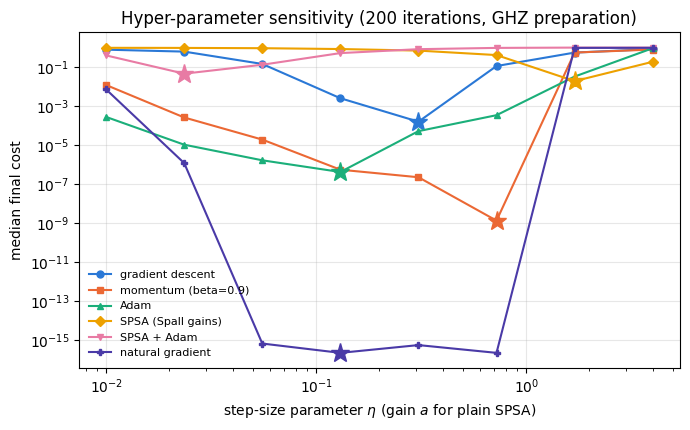


best step size per optimiser (stars in the figure):
        gradient descent: 0.306825
     momentum (beta=0.9): 0.722128
                    Adam: 0.130367
      SPSA (Spall gains): 1.69956
             SPSA + Adam: 0.0235355
        natural gradient: 0.130367


In [12]:
# ==============================================================================
# STEP 9: nested vmap -- one compilation for a whole (learning rate x initialisation) sweep
# ==============================================================================
A_SPSA = 30.0                      # Spall's stability constant, ~10% of the iteration budgets used below


def sweep_lr(make_opt, grad_rule, monitor, thetas, keys, lr_values, n_steps):
    """Final cost of every (learning rate, initialisation) pair, in ONE compiled program.

    JAX   nested vmap: outer over learning rates (traced scalars, so `make_opt(lr)` compiles once for all of them),
          inner over initialisations. Returns an array of shape (n_lr, n_runs, n_steps).
    """
    def one_lr(lr):
        return jax.vmap(lambda t, k: train(t, k, grad_rule, make_opt(lr), monitor, n_steps)[1])(thetas, keys)
    return jax.jit(jax.vmap(one_lr))(lr_values)


def tune(configs, monitor, thetas, keys, lr_values, n_steps, title):
    """Run `sweep_lr` for every configuration, print the table, plot it, and return the best rate of each."""
    best = {}
    fig, ax = plt.subplots(figsize=(7.0, 4.4))
    print(f"median final cost after {n_steps} iterations, {thetas.shape[0]} random starts")
    print(f"{'optimiser':>22s} | " + "  ".join(f"{float(l):8.3g}" for l in lr_values))
    for j, (name, mk, gr) in enumerate(configs):
        H = np.asarray(sweep_lr(mk, gr, monitor, thetas, keys, lr_values, n_steps))
        med = np.median(H[:, :, -1], axis=1)
        med = np.where(np.isfinite(med), med, np.inf)            # a diverged learning rate must never "win"
        best[name] = float(lr_values[int(np.argmin(med))])
        print(f"{name:>22s} | " + "  ".join(f"{m:8.2e}" for m in med))
        ax.loglog(np.asarray(lr_values), np.maximum(med, 1e-18), MARKERS[j] + "-", ms=5, color=PALETTE[j], label=name)
        ax.plot([best[name]], [max(med.min(), 1e-18)], "*", ms=14, color=PALETTE[j])
    ax.set_xlabel(r"step-size parameter $\eta$ (gain $a$ for plain SPSA)")
    ax.set_ylabel("median final cost")
    ax.set_title(title); ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()
    print("\nbest step size per optimiser (stars in the figure):")
    for k, v in best.items():
        print(f"  {k:>22s}: {v:g}")
    return best


def configs_for(cost, state_fn):
    """The six optimisers of this notebook, as (name, learning-rate -> optimiser, gradient rule) triples."""
    return [("gradient descent", lambda lr: opt_gd(lr), grad_exact(cost)),
            ("momentum (beta=0.9)", lambda lr: opt_momentum(lr, 0.9), grad_exact(cost)),
            ("Adam", lambda lr: opt_adam(lr), grad_exact(cost)),
            ("SPSA (Spall gains)", lambda a: opt_spsa_step(a, A_SPSA), grad_spsa_exact(cost, c=0.2)),
            ("SPSA + Adam", lambda lr: opt_adam(lr), grad_spsa_exact(cost, c=0.2)),
            ("natural gradient", lambda lr: opt_gd(lr), grad_qng(cost, state_fn))]


N_RUNS_SWEEP, N_STEPS_SWEEP = 12, 200
th_s, ks_s = random_starts(N_RUNS_SWEEP, N_PAR, seed=200)
lr_grid = jnp.asarray(np.geomspace(0.01, 4.0, 8))
best_lr = tune(configs_for(cost_ghz, state_ghz), cost_ghz, th_s, ks_s, lr_grid, N_STEPS_SWEEP,
               f"Hyper-parameter sensitivity ({N_STEPS_SWEEP} iterations, GHZ preparation)")

Every row depends strongly on the step size, and the stability bounds of Sections 4 to 6 explain where each row fails.

* **Gradient descent** spans almost four orders of magnitude across the grid, with a sharp optimum at $\eta=0.31$ and a
  final cost of $1.5\cdot10^{-4}$. Its optimum sits below the $2/\lambda_{\max}=0.577$ measured in Section 4.3, as
  Eq. (5) requires; the next grid point up, $0.72$, is past the bound and the cost is three orders of magnitude higher.
* **Momentum** is best at $\eta=0.72$, above gradient descent's stability limit. The heavy-ball bound is different:
  the characteristic polynomial $\mu^2-(1+\beta-\eta\lambda)\mu+\beta$ of Eq. (8) has a root at $\mu=-1$ when
  $1+(1+\beta-\eta\lambda)+\beta=0$, so the iteration is stable for $\eta<2(1+\beta)/\lambda_{\max}$, which is
  $3.8/3.46=1.10$ for $\beta=0.9$ at the minimum of Section 4.3. Momentum therefore admits a larger step as well as giving
  a better rate. The next grid point, $\eta=1.7$, is past this bound, and the run fails there.
* **Adam** stays below $10^{-4}$ from $\eta=0.024$ to $0.31$, just over a decade, and never diverges: even at
  $\eta=4$ its median cost is $0.88$, close to the $1-1/16=0.94$ of a random four-qubit state, as Section 6.3 predicts
  for a method whose step does not grow with the gradient. Its best value, $4\cdot10^{-7}$, is far above those of
  momentum ($1.3\cdot10^{-9}$) and the natural gradient. The convergence curves of Section 12 show the same: at its
  tuned $\eta$ Adam's median infidelity fluctuates between about $10^{-7}$ and $10^{-5}$ after 150 iterations while
  momentum keeps converging geometrically.
* **The natural gradient** stays below $10^{-4}$ over the widest window of the six, from $0.024$ to $0.72$ (one and a half
  decades), reaches machine precision, $2\cdot10^{-16}$, from $0.055$ to $0.72$, and fails at $\eta=1.7$. That bound
  can be derived. Near a minimum where the infidelity vanishes, Eq. (16) says $C=1-F\approx\boldsymbol\delta^{\mathsf T}
  \mathbf G\boldsymbol\delta$, so the Hessian of $C$ is $2\mathbf G$ (checked numerically in Section 9). The update of
  Eq. (18) then multiplies the error along a metric eigenvector with eigenvalue $g$ by
  $1-2\eta g/(g+\lambda_{\mathrm{reg}})\approx1-2\eta$: the natural gradient is stable for $\eta<1$, independently of
  the curvature, and $\eta=\tfrac12$ is a Newton step.
* **Both SPSA rows stay far behind.** In 200 iterations the best they manage is $1.8\cdot10^{-2}$ and
  $4.4\cdot10^{-2}$, two to fourteen orders of magnitude behind the exact-gradient methods at *the same iteration
  count*. That is the expected price of one scalar of information per step, and Section 12 gives them more iterations.

The starred values are used in Section 12. These are medians over 12 starts on a grid with a factor of $2.35$ between
neighbouring points, so each optimum is known only to within a grid step. The momentum $\beta=0.9$, Adam's
$\beta_1,\beta_2,\epsilon$, SPSA's $c=0.2$ and $A=30$, and the ridge $\lambda_{\mathrm{reg}}=10^{-3}$ are fixed at
their standard values and were not tuned, and Sections 13 (shot noise) and 14 use Adam at $\eta=0.05$ without
re-tuning.

> **Common pitfall.** Comparing optimisers at a single shared learning rate is meaningless — it measures which
> optimiser happens to like that number. Each method must be given its own best setting, found on the same problem with
> the same budget, as above.

## 12. Benchmark 1: preparing a GHZ state

The problem: minimise $C=1-\lvert\langle\mathrm{GHZ}\vert\psi(\boldsymbol\theta)\rangle\rvert^2$ for $N=4$ qubits with
a hardware-efficient ansatz of $L=3$ layers ($n=32$ angles), from 24 uniformly random starts, for 400 iterations.
Six methods compete, each at its measured best learning rate.

The metrics are the ones that matter for a device:

* **success rate** — the fraction of random starts that reach infidelity $<10^{-3}$ at some iteration within the budget,
  with a 95% Wilson interval: for $k$ successes in $R$ runs and $p=k/R$, the interval is
  $\bigl[p+\tfrac{z^2}{2R}\mp z\sqrt{p(1-p)/R+z^2/4R^2}\bigr]/(1+z^2/R)$ with $z=1.96$. With $R=24$ the interval for
  $24/24$ is $[0.86,1]$, so differences of a few runs are not resolved;
* **median iterations** to that target, over the successful runs;
* **median circuit evaluations** to that target. This is the currency of a device: we *count* what each method would cost on
  hardware per iteration — $2n$ circuits for a parameter-shift gradient, $2$ for SPSA, $2n+n(n+1)/2$ for the natural
  gradient with the full metric — and multiply.

In [13]:
# ==============================================================================
# STEP 10: the six-way benchmark on GHZ preparation
# ==============================================================================
def circuits_per_iteration(name, n):
    """How many circuit executions one iteration of `name` would need on hardware, COUNTED from the algorithm.

    parameter-shift gradient : 2n         (notebook 40, Eq. (18))
    SPSA                     : 2          (notebook 40, Eq. (20))
    natural gradient         : 2n + n(n+1)/2   -- the gradient plus one overlap circuit per metric entry
    """
    if name.startswith("SPSA"):
        return 2
    if name == "natural gradient":
        return 2 * n + n * (n + 1) // 2
    return 2 * n


def build_methods(configs, best, n):
    """Instantiate each configuration at its measured best step size, with its counted circuit cost."""
    return [(name, mk(best[name]), gr, circuits_per_iteration(name, n)) for name, mk, gr in configs]


N_RUNS, N_STEPS, TARGET = 24, 400, 1e-3
th_b, ks_b = random_starts(N_RUNS, N_PAR, seed=300)
METHODS = build_methods(configs_for(cost_ghz, state_ghz), best_lr, N_PAR)

hists, rows = {}, []
for name, opt, gr, ev in METHODS:
    _, h, t_c, t_r = train_many_timed(th_b, ks_b, gr, opt, cost_ghz, N_STEPS)
    h = np.asarray(h)
    hists[name] = h
    r = summarise(name, h, TARGET, ev)
    r["compile"], r["run"], r["ev_per_iter"] = t_c, t_r, ev
    rows.append(r)

print(f"GHZ preparation, N={N_GHZ}, L={L_GHZ}, n={N_PAR}; {N_RUNS} random starts, {N_STEPS} iterations, "
      f"target infidelity {TARGET:g}")
print(f"{'optimiser':>22s} {'success':>8s} {'95% CI':>13s} {'med iters':>10s} {'circ/iter':>10s} {'med circuits':>13s} "
      f"{'median final':>13s} {'best final':>12s} {'compile [s]':>12s} {'run [s]':>8s}")
for r in rows:
    it = f"{r['iters']:.0f}" if np.isfinite(r["iters"]) else "-"
    ev = f"{r['evals']:.3g}" if np.isfinite(r["evals"]) else "-"
    lo, hi = wilson_interval(round(r["success"] * N_RUNS), N_RUNS)
    print(f"{r['name']:>22s} {r['success']:8.2f} {f'[{lo:.2f}, {hi:.2f}]':>13s} {it:>10s} {r['ev_per_iter']:10d} "
          f"{ev:>13s} {r['median_final']:13.2e} {r['best']:12.2e} {r['compile']:12.2f} {r['run']:8.2f}")

GHZ preparation, N=4, L=3, n=32; 24 random starts, 400 iterations, target infidelity 0.001
             optimiser  success        95% CI  med iters  circ/iter  med circuits  median final   best final  compile [s]  run [s]
      gradient descent     1.00  [0.86, 1.00]        118         64      7.52e+03      1.92e-05     4.74e-13         1.40     0.43
   momentum (beta=0.9)     1.00  [0.86, 1.00]         62         64      3.94e+03      3.86e-14    -8.88e-16         1.27     0.42
                  Adam     1.00  [0.86, 1.00]         56         64      3.58e+03      8.45e-08     0.00e+00         1.17     0.84
    SPSA (Spall gains)     0.12  [0.04, 0.31]        327          2           654      3.73e-03     8.64e-04         1.20     0.38
           SPSA + Adam     0.00  [0.00, 0.14]          -          2             -      5.26e-03     1.39e-03         1.22     0.36
      natural gradient     1.00  [0.86, 1.00]         22        592       1.3e+04      4.44e-16    -4.44e-16         2.43  

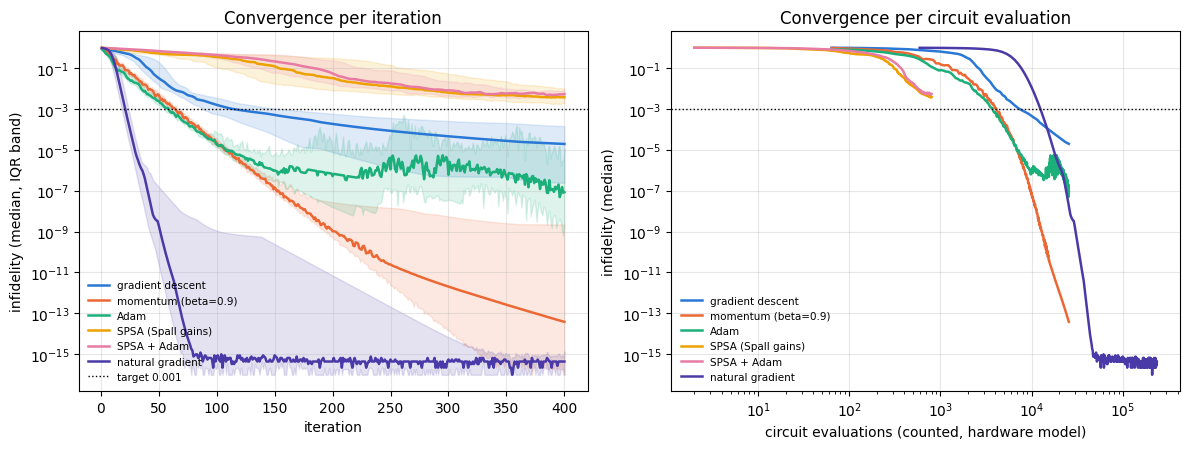

In [14]:
# ==============================================================================
# STEP 11: convergence curves with interquartile bands
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
it_axis = np.arange(1, N_STEPS + 1)
for j, (name, _, _, ev) in enumerate(METHODS):
    lo, med, hi = bands(np.maximum(hists[name], 1e-16))
    axes[0].fill_between(it_axis, lo, hi, color=PALETTE[j], alpha=0.15)
    axes[0].semilogy(it_axis, med, "-", lw=1.8, color=PALETTE[j], label=name)
    axes[1].loglog(it_axis * ev, med, "-", lw=1.8, color=PALETTE[j], label=name)
axes[0].axhline(TARGET, color="k", ls=":", lw=1, label=f"target {TARGET:g}")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("infidelity (median, IQR band)")
axes[0].set_title("Convergence per iteration"); axes[0].legend(fontsize=7.5)
axes[1].axhline(TARGET, color="k", ls=":", lw=1)
axes[1].set_xlabel("circuit evaluations (counted, hardware model)")
axes[1].set_ylabel("infidelity (median)")
axes[1].set_title("Convergence per circuit evaluation"); axes[1].legend(fontsize=7.5)
fig.tight_layout(); plt.show()

The two panels rank the methods differently.

**Per iteration** (left panel) the natural gradient needs a median of $22$ iterations to reach $10^{-3}$, Adam $56$,
momentum $62$, plain gradient descent $118$. All four succeed from **every one** of the 24 random starts (95% interval
$[0.86,1]$). The two SPSA rows do not: plain SPSA reaches the target from $3$ of $24$ starts within 400 iterations
($0.12$, interval $[0.04,0.31]$), and SPSA with Adam from none ($[0,0.14]$), ending at a median infidelity of
$5\cdot10^{-3}$. Exact-gradient methods use $n=32$ numbers of information per step; SPSA uses one. Both SPSA rows were
still improving at iteration 400 (left panel); they failed to arrive within the budget rather than being
trapped in local minima.

**Per circuit evaluation** (right panel) the ranking is different, because an exact gradient costs $2n=64$ circuits and
the natural gradient $2n+n(n+1)/2=592$, while an SPSA step costs $2$. Adam needs a median of $3.6\cdot10^{3}$ circuits,
momentum $3.9\cdot10^{3}$, gradient descent $7.5\cdot10^{3}$, and the natural gradient $1.3\cdot10^{4}$ — its
twenty-two iterations are the most expensive in the table. The method that wins the left panel loses the right one.

The SPSA row of the circuit column reads $654$, the lowest in the table, but it is the median over the 3 runs that
succeeded and says nothing about the other 21. **The success probability has to be read before the iteration
count**: a method that needs restarts pays for every failed one, and the expected cost per success is the cost per run
divided by the success probability.

> **Numerical practice.** The "best final" column contains values like $-4\cdot10^{-16}$. An infidelity cannot be
> negative; what this means is that $\lvert\langle\phi\vert\psi\rangle\rvert^2$ was computed as slightly greater than
> one in floating point, and $1-F$ inherited the round-off. A value of $-10^{-16}$ means the optimiser reached the
> target to machine precision.

## 13. Benchmark 2: the ground energy of a transverse-field Ising chain

The second benchmark is a physics problem with an exactly known answer. Take the transverse-field Ising model

$$H=J\sum_{q=0}^{N-2}Z_qZ_{q+1}+h\sum_{q=0}^{N-1}X_q ,\qquad J=1,\ h=0.8,$$

on an open chain of $N=6$ spins, and minimise $C(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert H
\vert\psi(\boldsymbol\theta)\rangle$. The variational principle guarantees $C\ge E_0$, and $E_0$ is available exactly
from the Lanczos ground state of
[11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb),
so the quantity to plot is the **energy error** $C-E_0$, which must stay positive.

(The full physics of this optimised state — its fidelity with the true ground state, its entanglement, its correlation
functions — is the subject of
[42 — the variational quantum eigensolver](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb).
Here we use it only as a landscape on which to compare optimisers.)

In [15]:
# ==============================================================================
# STEP 12: the TFIM problem and its exact ground energy
# ==============================================================================
N_H, L_H, J_H, HX_H = 6, 3, 1.0, 0.8
N_PAR_H = hea_num_params(N_H, L_H)
terms_H = heisenberg_terms(N_H, Jxx=0.0, Jyy=0.0, Jzz=J_H, hx=HX_H)
E0, _ = lanczos_ground_state(terms_H, N_H)
E0_dense = float(np.min(np.linalg.eigvalsh(np.asarray(dense_hamiltonian(terms_H, N_H)))))
print(f"TFIM, N={N_H}, J={J_H}, h={HX_H}: ground energy")
print(f"  Lanczos            E0 = {E0:.12f}")
print(f"  dense eigenvalues  E0 = {E0_dense:.12f}   difference {abs(E0 - E0_dense):.1e}")
assert abs(E0 - E0_dense) < 1e-8

cost_H = jax.jit(lambda t: energy(terms_H, hardware_efficient_ansatz(t, N_H, L_H)))
err_H = jax.jit(lambda t: cost_H(t) - E0)
state_H = lambda t: hardware_efficient_ansatz(t, N_H, L_H)

TFIM, N=6, J=1.0, h=0.8: ground energy
  Lanczos            E0 = -6.439709730751
  dense eigenvalues  E0 = -6.439709730751   difference 2.4e-14


The energy has a different scale from an infidelity (it runs over several units rather than over $[0,1]$), so the step
sizes tuned in Section 11 cannot simply be carried over: for gradient descent and momentum a learning rate is an inverse
curvature, and curvature carries the units of the cost. We therefore re-tune on this problem, with a shorter sweep.

median final cost after 120 iterations, 6 random starts
             optimiser |     0.01    0.0259    0.0669     0.173     0.448      1.16         3


      gradient descent | 9.65e-01  2.11e-01  1.25e-01  1.15e-01  1.68e-01  4.36e+00  5.38e+00


   momentum (beta=0.9) | 1.17e-01  1.09e-01  1.06e-01  1.01e-01  1.02e-01  6.63e+00  6.48e+00


                  Adam | 1.93e-01  1.15e-01  1.09e-01  1.03e-01  9.64e-02  9.92e-02  9.90e-01


    SPSA (Spall gains) | 5.18e+00  4.36e+00  3.00e+00  1.28e+00  3.01e-01  3.35e+00  5.94e+00


           SPSA + Adam | 3.20e+00  1.52e+00  9.06e-01  2.74e+00  4.67e+00  6.07e+00  6.08e+00


      natural gradient | 1.10e-01  6.61e-02  1.94e-02  1.40e-01  6.21e+00  6.87e+00  6.64e+00


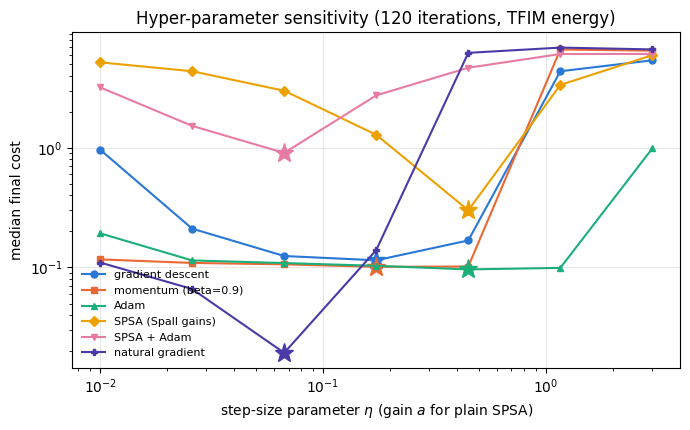


best step size per optimiser (stars in the figure):
        gradient descent: 0.173205
     momentum (beta=0.9): 0.173205
                    Adam: 0.44814
      SPSA (Spall gains): 0.44814
             SPSA + Adam: 0.0669433
        natural gradient: 0.0669433


In [16]:
# ==============================================================================
# STEP 13: re-tuning the step sizes on the energy landscape
# ==============================================================================
N_RUNS_SWEEP_H, N_STEPS_SWEEP_H = 6, 120
th_sh, ks_sh = random_starts(N_RUNS_SWEEP_H, N_PAR_H, seed=350)
lr_grid_H = jnp.asarray(np.geomspace(0.01, 3.0, 7))
best_lr_H = tune(configs_for(cost_H, state_H), err_H, th_sh, ks_sh, lr_grid_H, N_STEPS_SWEEP_H,
                 f"Hyper-parameter sensitivity ({N_STEPS_SWEEP_H} iterations, TFIM energy)")


energy error E - E0; 16 random starts, 300 iterations, target 0.05
             optimiser  success        95% CI  med iters  circ/iter  med circuits  median final   best final  min E - E0 < 0?  compile/run [s]
      gradient descent     0.00  [0.00, 0.19]          -         96             -      1.14e-01     1.02e-01            False    2.13/0.59    
   momentum (beta=0.9)     0.00  [0.00, 0.19]          -         96             -      9.35e-02     8.56e-02            False    2.22/0.69    
                  Adam     0.06  [0.01, 0.28]        203         96      1.95e+04      9.01e-02     3.57e-02            False    1.53/0.76    
    SPSA (Spall gains)     0.00  [0.00, 0.19]          -          2             -      1.49e-01     1.20e-01            False    1.77/0.49    
           SPSA + Adam     0.00  [0.00, 0.19]          -          2             -      4.91e-01     2.10e-01            False    1.73/0.54    
      natural gradient     0.94  [0.72, 0.99]         89       1272      1

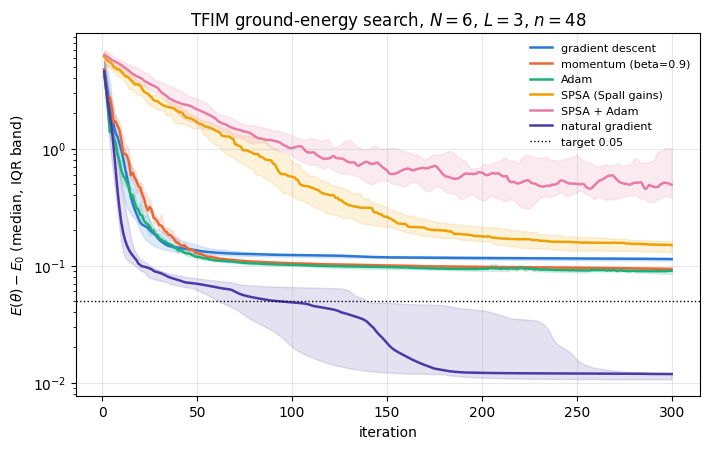

In [17]:
# ==============================================================================
# STEP 14: the benchmark on the energy landscape
# ==============================================================================
N_RUNS_H, N_STEPS_H, TARGET_H = 16, 300, 5e-2
th_h, ks_h = random_starts(N_RUNS_H, N_PAR_H, seed=400)
METHODS_H = build_methods(configs_for(cost_H, state_H), best_lr_H, N_PAR_H)

hists_H, rows_H = {}, []
for name, opt, gr, ev in METHODS_H:
    _, h, t_c, t_r = train_many_timed(th_h, ks_h, gr, opt, err_H, N_STEPS_H)
    h = np.asarray(h)
    hists_H[name] = h
    r = summarise(name, h, TARGET_H, ev); r["compile"], r["run"], r["ev_per_iter"] = t_c, t_r, ev
    rows_H.append(r)

print(f"\nenergy error E - E0; {N_RUNS_H} random starts, {N_STEPS_H} iterations, target {TARGET_H:g}")
print(f"{'optimiser':>22s} {'success':>8s} {'95% CI':>13s} {'med iters':>10s} {'circ/iter':>10s} {'med circuits':>13s} "
      f"{'median final':>13s} {'best final':>12s} {'min E - E0 < 0?':>16s} {'compile/run [s]':>16s}")
for r, (name, _, _, _) in zip(rows_H, METHODS_H):
    it = f"{r['iters']:.0f}" if np.isfinite(r["iters"]) else "-"
    ev = f"{r['evals']:.3g}" if np.isfinite(r["evals"]) else "-"
    lo, hi = wilson_interval(round(r["success"] * N_RUNS_H), N_RUNS_H)
    print(f"{r['name']:>22s} {r['success']:8.2f} {f'[{lo:.2f}, {hi:.2f}]':>13s} {it:>10s} {r['ev_per_iter']:10d} "
          f"{ev:>13s} {r['median_final']:13.2e} {r['best']:12.2e} {str(bool(np.any(hists_H[name] < -1e-9))):>16s} "
          f"{r['compile']:7.2f}/{r['run']:<8.2f}")
succ_H = {r["name"]: round(r["success"] * N_RUNS_H) for r in rows_H}
ci_qng, ci_adam = wilson_interval(succ_H["natural gradient"], N_RUNS_H), wilson_interval(succ_H["Adam"], N_RUNS_H)
print(f"\n95% intervals: natural gradient {ci_qng[0]:.2f}-{ci_qng[1]:.2f}, Adam {ci_adam[0]:.2f}-{ci_adam[1]:.2f} "
      f"-> {'disjoint' if ci_qng[0] > ci_adam[1] else 'overlapping'}")

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for j, (name, _, _, _) in enumerate(METHODS_H):
    lo, med, hi = bands(np.maximum(hists_H[name], 1e-16))
    ax.fill_between(np.arange(1, N_STEPS_H + 1), lo, hi, color=PALETTE[j], alpha=0.15)
    ax.semilogy(np.arange(1, N_STEPS_H + 1), med, "-", lw=1.8, color=PALETTE[j], label=name)
ax.axhline(TARGET_H, color="k", ls=":", lw=1, label=f"target {TARGET_H:g}")
ax.set_xlabel("iteration"); ax.set_ylabel(r"$E(\theta)-E_0$ (median, IQR band)")
ax.set_title(f"TFIM ground-energy search, $N={N_H}$, $L={L_H}$, $n={N_PAR_H}$")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**The variational principle holds throughout.** In $6\times16\times300$ recorded energies the error $E-E_0$ never went
negative — a free correctness check that the cost function, the Hamiltonian term list and the Lanczos reference are
mutually consistent.

**The optimal step sizes moved.** Adam's best step went from $0.13$ on the infidelity landscape to $0.45$ on the energy
landscape, and the natural gradient's from $0.13$ to $0.067$. How much that matters differs between the two. Adam's
energy sweep is flat (median final error between $0.096$ and $0.115$ from $\eta=0.026$ to $1.16$), so its choice is
not critical here. The natural gradient's usable window is narrow and lies much lower than on the GHZ problem: the
sweep fails from $\eta=0.45$ on, and the check outside the notebook placed the edge between $0.17$ and $0.2$. The bound
$\eta<1$ of Section 11 holds for an infidelity cost, whose Hessian at the minimum is $2\mathbf G$; the Hessian of an
energy is not tied to the metric in this way.

**Within 300 iterations this landscape is much harder than the GHZ one.** Four of the six methods never reach an
energy error of $0.05$ from any start (95% interval $[0,0.19]$ for 0 of 16): gradient descent, momentum and plain SPSA
end between $0.09$ and $0.15$, SPSA with Adam at a median of $0.49$. Adam crosses the target from $1$ start in $16$
($[0.01,0.28]$). **The natural gradient succeeds from 15 of the 16 starts** ($[0.72,0.99]$), with a median of $89$
iterations; the best single run of the section, $8.6\cdot10^{-3}$, is also its. With 16 runs per method the difference
between 15 and 1 successes is far outside the sampling error: the two Wilson intervals printed below the table are
disjoint, and Fisher's exact test gives $p<10^{-5}$.

Two questions decide what this comparison means: whether Adam's step size was chosen fairly for this criterion, and
whether the other methods are stuck or only slow. The tuning sweep picked each step size by the median *final* energy
after 120 iterations from 6 starts, which is a different criterion from the success rate after 300 iterations. A
separate check outside this notebook ran every method at 13 step sizes from 64 starts (the 16 used here and 48 new
ones) for 300 iterations. Adam's best success rate over that grid was $13/64=0.20$ (at $\eta=0.6$, interval
$[0.12,0.32]$), momentum's $11/64$, gradient descent's $0$, and the natural gradient's $61/64=0.95$ ($[0.87,0.98]$). The
ranking at 300 iterations survives fair tuning; the gap shrinks from 94% against 6% to 95% against 20%.

The second question is answered by the cell below, which repeats the three exact-gradient methods at their tuned step
sizes with a ten times larger iteration budget.

In [18]:
# ==============================================================================
# STEP 14b: control -- the same starts with 3000 instead of 300 iterations
# ==============================================================================
N_STEPS_LONG = 3000
print(f"{'optimiser':>22s} {'success':>8s} {'95% CI':>13s} {'by it. 300':>11s} {'med iters':>10s} {'med circuits':>13s} "
      f"{'median final':>13s} {'best final':>12s} {'run [s]':>8s}")
for name, opt, gr, ev in METHODS_H[:3]:                       # gradient descent, momentum, Adam
    _, h, t_c, t_r = train_many_timed(th_h, ks_h, gr, opt, err_H, N_STEPS_LONG)
    r = summarise(name, np.asarray(h), TARGET_H, ev)
    k_ok = round(r["success"] * N_RUNS_H)
    lo, hi = wilson_interval(k_ok, N_RUNS_H)
    by300 = int(np.sum(np.any(np.asarray(h)[:, :N_STEPS_H] < TARGET_H, axis=1)))
    it = f"{r['iters']:.0f}" if np.isfinite(r["iters"]) else "-"
    evs = f"{r['evals']:.3g}" if np.isfinite(r["evals"]) else "-"
    print(f"{name:>22s} {r['success']:8.2f} {f'[{lo:.2f}, {hi:.2f}]':>13s} {by300:>11d} {it:>10s} {evs:>13s} "
          f"{r['median_final']:13.2e} {r['best']:12.2e} {t_r:8.1f}")

             optimiser  success        95% CI  by it. 300  med iters  med circuits  median final   best final  run [s]


      gradient descent     0.00  [0.00, 0.19]           0          -             -      9.55e-02     7.21e-02      7.0


   momentum (beta=0.9)     0.75  [0.51, 0.90]           0       1392      1.34e+05      3.33e-02     8.72e-03      6.4


                  Adam     0.94  [0.72, 0.99]           1        603      5.79e+04      2.60e-02     8.95e-03      6.3


With 3000 iterations Adam reaches the target from 15 of the 16 starts (interval $[0.72,0.99]$), after a median of about
600 iterations, and momentum from 12 ($[0.51,0.90]$), after about 1400; only gradient descent stays above $0.05$. (The
check outside the notebook, with the same starts and keys but a separately written program, gave 16 of 16 for Adam:
over 3000 iterations of a non-convex problem, round-off differences between two compiled programs grow until single
trajectories differ, so only the statistics, not individual runs, carry over from one program to another.) The level near $E-E_0\approx0.1$ where the curves of the
figure flatten is therefore a slow region rather than a set of local minima. The check outside the notebook also
diagonalised the Hessian at four of Adam's iterates after 300 iterations: the gradient norm is $2\cdot10^{-3}$ to
$2\cdot10^{-2}$, the largest Hessian eigenvalue is about $6$, and there are two or three *negative* eigenvalues of only
$-2\cdot10^{-3}$ to $-4\cdot10^{-3}$. These are saddle regions with an escape direction whose curvature is three
thousand times weaker than the steepest direction, so a Euclidean method leaves them only slowly. Rescaled by the metric,
i.e. for the matrix $(\mathbf G+\lambda_{\mathrm{reg}}\mathbb 1)^{-1}\mathbf H$ that governs the natural-gradient
iteration, the same negative eigenvalues become $-2$ to $-3$ against a largest eigenvalue of about $14$: the escape
direction is no longer weak, and the natural gradient leaves the saddle region in tens of iterations.

The circuit count reverses the conclusion about cost. At $2n+n(n+1)/2=96+1176=1272$ circuits per iteration ($n=48$) the
natural gradient spent a median of $1.1\cdot10^{5}$ circuits to reach the target; Adam, at $2n=96$ circuits per
iteration, needed $5.8\cdot10^{4}$ in the longer run, about half, and momentum $1.3\cdot10^{5}$. On this landscape the metric buys an order of magnitude in
iterations and a much higher success rate at a fixed small iteration budget, but not fewer circuits.

The final energies also show that the runs end in different minima. In the outside check (1000 iterations, same 16
starts) the natural-gradient runs end, all but one, at
$E-E_0=8.6\cdot10^{-3}$, $1.14\cdot10^{-2}$, $1.18\cdot10^{-2}$ or $1.20\cdot10^{-2}$ (the median $1.18\cdot10^{-2}$ in the
table is one of them); the lowest value found here, $8.6\cdot10^{-3}$, is an upper bound on the error of the best
$L=3$ circuit, which does not contain the exact ground state. How this error depends on the depth is the subject of
notebook 42.

TFIM, N=4, L=2, n=24: exact ground energy E0 = -4.14556091

6 random starts, 100 iterations; the monitored quantity is the EXACT energy error
                method  shots/circuit  shots/iteration   median final E-E0        IQR of final   best final


parameter shift + Adam             32             1536          2.4749e-01      [0.245, 0.309]   1.9352e-01


           SPSA + Adam             32               64          1.0959e+00      [0.863, 1.303]   6.1517e-01


parameter shift + Adam            128             6144          2.0106e-01      [0.175, 0.216]   6.1866e-02


           SPSA + Adam            128              256          5.3482e-01      [0.495, 0.590]   4.1117e-01


parameter shift + Adam            512            24576          1.7862e-01      [0.163, 0.182]   5.4339e-02


           SPSA + Adam            512             1024          4.2856e-01      [0.404, 0.597]   3.4240e-01


parameter shift + Adam, exact cost              -                -          1.7070e-01      [0.150, 0.176]   3.9629e-02


SPSA + Adam, exact cost              -                -          3.2880e-01      [0.314, 0.336]   2.1398e-01


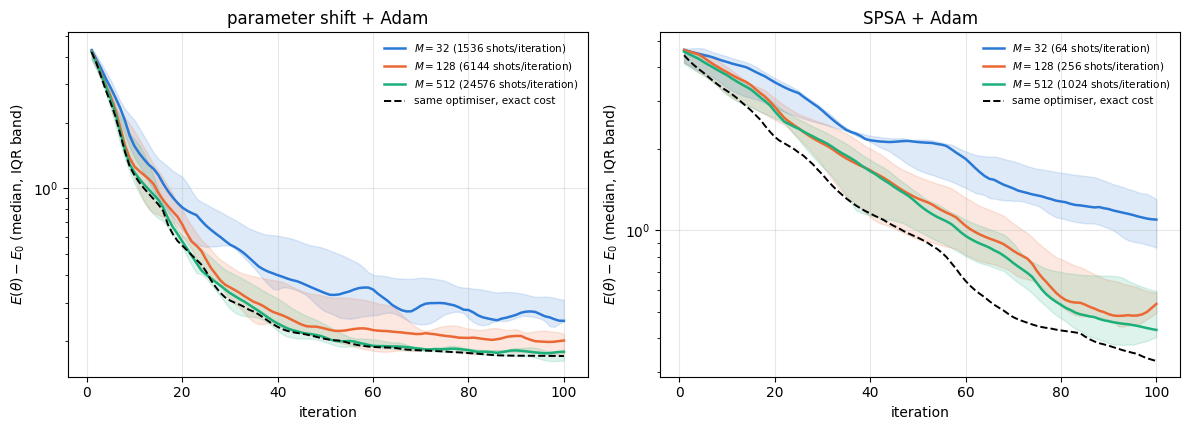

In [19]:
# ==============================================================================
# STEP 15: the same problem with SHOT-NOISY costs, at three shot budgets
# ==============================================================================
# Shots are expensive, so the noisy study uses the smaller chain N=4 and shorter runs.
N_SN, L_SN = 4, 2
N_PAR_SN = hea_num_params(N_SN, L_SN)
terms_SN = heisenberg_terms(N_SN, Jxx=0.0, Jyy=0.0, Jzz=J_H, hx=HX_H)
E0_SN, _ = lanczos_ground_state(terms_SN, N_SN)
cost_SN = jax.jit(lambda t: energy(terms_SN, hardware_efficient_ansatz(t, N_SN, L_SN)))
err_SN = jax.jit(lambda t: cost_SN(t) - E0_SN)
print(f"TFIM, N={N_SN}, L={L_SN}, n={N_PAR_SN}: exact ground energy E0 = {E0_SN:.8f}")


def energy_shots(key, psi, shots):
    """Unbiased estimate of <H_TFIM> from `shots` measurements: half in the Z basis, half in the X basis.

    MATH   a Z-basis shot gives all Z_q Z_{q+1} at once (z_q = 1 - 2*bit); an X-basis shot gives all X_q.
    COST   2 circuit executions of `shots`/2 repetitions each.
    """
    kz, kx = jax.random.split(key)
    half = shots // 2
    z = 1.0 - 2.0 * sample_bitstrings(kz, psi, half, bases="Z" * N_SN).astype(RDTYPE)
    x = 1.0 - 2.0 * sample_bitstrings(kx, psi, half, bases="X" * N_SN).astype(RDTYPE)
    return J_H * jnp.mean(jnp.sum(z[:, :-1] * z[:, 1:], axis=1)) + HX_H * jnp.mean(jnp.sum(x, axis=1))


def grad_ps_shots(M):
    """Parameter-shift gradient rule in which every one of the 2n circuits is estimated from M shots."""
    eye = jnp.eye(N_PAR_SN)

    def rule(theta, key, k):
        kp, km = jax.random.split(key)

        def one(e, k1, k2):
            cp = energy_shots(k1, hardware_efficient_ansatz(theta + (jnp.pi / 2) * e, N_SN, L_SN), M)
            cm = energy_shots(k2, hardware_efficient_ansatz(theta - (jnp.pi / 2) * e, N_SN, L_SN), M)
            return (cp - cm) / 2
        return jax.vmap(one)(eye, jax.random.split(kp, N_PAR_SN), jax.random.split(km, N_PAR_SN))
    return rule


def grad_spsa_shots(M, c=0.2, gamma=0.101):
    """SPSA gradient rule with both circuits estimated from M shots."""
    def rule(theta, key, k):
        c_k = c / k ** gamma
        kd, kp, km = jax.random.split(key, 3)
        delta = jax.random.rademacher(kd, theta.shape).astype(theta.dtype)
        cp = energy_shots(kp, hardware_efficient_ansatz(theta + c_k * delta, N_SN, L_SN), M)
        cm = energy_shots(km, hardware_efficient_ansatz(theta - c_k * delta, N_SN, L_SN), M)
        return (cp - cm) / (2 * c_k) * delta
    return rule


N_RUNS_SN, N_STEPS_SN = 6, 100
th_sn, ks_sn = random_starts(N_RUNS_SN, N_PAR_SN, seed=500)
SHOTS = (32, 128, 512)
noisy = {}
print(f"\n{N_RUNS_SN} random starts, {N_STEPS_SN} iterations; the monitored quantity is the EXACT energy error")
print(f"{'method':>22s} {'shots/circuit':>14s} {'shots/iteration':>16s} {'median final E-E0':>19s} "
      f"{'IQR of final':>19s} {'best final':>12s}")
for M in SHOTS:
    for label, gr, ev in (("parameter shift + Adam", grad_ps_shots(M), 2 * N_PAR_SN * M),
                          ("SPSA + Adam", grad_spsa_shots(M), 2 * M)):
        _, h = train_many(th_sn, ks_sn, gr, opt_adam(0.05), err_SN, N_STEPS_SN)
        h = np.asarray(jax.block_until_ready(h))
        noisy[(label, M)] = h
        q1, q3 = np.percentile(h[:, -1], [25, 75])
        print(f"{label:>22s} {M:14d} {ev:16d} {float(np.median(h[:, -1])):19.4e} {f'[{q1:.3f}, {q3:.3f}]':>19s} "
              f"{float(np.min(h[:, -1])):12.4e}")

# exact-cost references: the SAME optimiser, with the shot noise switched off
refs = {}
for label, gr in (("parameter shift + Adam", grad_exact(cost_SN)),
                  ("SPSA + Adam", grad_spsa_exact(cost_SN, c=0.2))):
    _, h = train_many(th_sn, ks_sn, gr, opt_adam(0.05), err_SN, N_STEPS_SN)
    refs[label] = np.asarray(jax.block_until_ready(h))
    q1, q3 = np.percentile(refs[label][:, -1], [25, 75])
    print(f"{label + ', exact cost':>22s} {'-':>14s} {'-':>16s} {float(np.median(refs[label][:, -1])):19.4e} "
          f"{f'[{q1:.3f}, {q3:.3f}]':>19s} {float(np.min(refs[label][:, -1])):12.4e}")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
it_sn = np.arange(1, N_STEPS_SN + 1)
for a, (label, ev_of) in zip(axes, (("parameter shift + Adam", lambda M: 2 * N_PAR_SN * M),
                                    ("SPSA + Adam", lambda M: 2 * M))):
    for j, M in enumerate(SHOTS):
        lo, med, hi = bands(np.maximum(noisy[(label, M)], 1e-16))
        a.fill_between(it_sn, lo, hi, color=PALETTE[j], alpha=0.15)
        a.semilogy(it_sn, med, "-", lw=1.8, color=PALETTE[j], label=f"$M={M}$ ({ev_of(M)} shots/iteration)")
    _, med, _ = bands(np.maximum(refs[label], 1e-16))
    a.semilogy(it_sn, med, "k--", lw=1.4, label="same optimiser, exact cost")
    a.set_xlabel("iteration"); a.set_ylabel(r"$E(\theta)-E_0$ (median, IQR band)")
    a.set_title(label); a.legend(fontsize=7.5)
fig.tight_layout(); plt.show()

Each panel carries its own dashed reference: the *same optimiser* with the shot noise switched off. That isolates the
effect of the shots from the convergence speed of the method.

**Shot noise adds an excess error at a fixed iteration count, and the excess falls as $M$ grows.** None of these runs
has converged after 100 iterations (the dashed curves are still falling), so the numbers compare the noisy and the
noise-free optimiser at the same iteration; they are not converged floors. For parameter shift with Adam the median energy
error at iteration 100 is $0.247$ at $M=32$, $0.201$ at $M=128$ and $0.179$ at $M=512$, against $0.171$ with the exact
cost; at $M=512$ the median curve in the left panel follows the dashed line over the whole run. For SPSA with Adam the
same progression is $1.10\to0.53\to0.43$ against an exact-cost reference of $0.329$. With 6 starts these medians are
rough: the interquartile ranges in the table overlap for neighbouring $M$, so only the trend over the factor 16 in $M$,
and the large gap at $M=32$, are resolved. The runs at different $M$ share their starting points, which makes the
comparison paired and the trend more reliable than the overlap of the ranges suggests.

**The shot counts differ between the rows.** One energy estimate uses $M$ shots, $M/2$ in each of the two
measurement bases. At the same $M$ a parameter-shift iteration needs $2n=48$ energy estimates and an SPSA iteration $2$,
so the shots per iteration differ by a factor $24$: at $M=512$ that is $24576$ shots per iteration against $1024$. This
experiment fixes the *iteration* count, so it measures what the shots cost per step, and parameter shift is closer to
its noise-free run there. It does **not** measure which method is better at a fixed total shot budget, where SPSA would
be granted $24$ times as many iterations.

Both rules also run at the same, untuned Adam step $\eta=0.05$, so the cell does not by itself rank them. A check
outside the notebook supplied the fair-tuning control, from 16 starts (the 6 used here and 10 more) and a step-size
scan with the optimum bracketed for each rule. At $M=128$ and 100 iterations each rule's best step was $\eta=0.05$
(median errors $0.19$ for parameter shift and $0.53$ for SPSA). At an *equal total* budget, 100 parameter-shift
iterations against 2400 SPSA iterations with $M=128$ each, the best steps were $0.05$ and $0.00625$, and the median
errors $0.191$ and $0.232$; the paired comparison over the 16 common starts (Wilcoxon signed-rank test) gives
$p=3\cdot10^{-5}$. On this problem parameter shift keeps a modest advantage at equal shots when both are tuned, much
smaller than the factor of two between the dashed lines suggests.

> **Numerical practice.** The monitored curve is the *exact* energy error, not the noisy estimate the optimiser sees.
> A fresh noisy estimate of the energy at the current angles is unbiased, but it scatters by one standard error
> $\sigma/\sqrt M$ around the true value, and reporting the lowest noisy value seen during a run, or the best of several
> runs, selects downward fluctuations and makes every method look better than it is. A real experiment must therefore
> re-measure its final angles with a much larger, independent shot budget.

## 14. Local minima, depth, and overparametrisation

Section 13 showed runs ending in different minima of the energy landscape, with energies between
$8.6\cdot10^{-3}$ and $1.2\cdot10^{-2}$ above the ground state. A landscape has minima that are not global, and which
of them a run falls into is decided by the initialisation. How many such minima there are, and how often they trap a
run, depends on the **number of parameters relative to the dimension of the state manifold being targeted**.

The heuristic, analysed for example by Larocca *et al.* (2023): when the ansatz has *just* enough parameters to reach
the target, the solution set is a small collection of isolated points and many basins lead elsewhere; when it has many
more, the solution set becomes a high-dimensional manifold that is easy to hit from anywhere. Adding layers
makes each iteration more expensive but can make the optimisation qualitatively easier.

We measure this on a deliberately hard target: a **Haar-random state** of four qubits, which has no structure for the
ansatz to exploit and needs $2\cdot2^N-2=30$ real parameters to specify. The ansatz has $n=2N(L+1)=8(L+1)$, so
$L=3$ is the first depth with $n\ge30$.

target: Haar-random state of N=4 qubits (needs 2*2^N-2 = 30 real parameters to specify)
  L  n = 2N(L+1)  success rate   median final    best final  median iters to target


  1           16          0.00       2.92e-01      2.92e-01                       -


  2           24          0.00       1.11e-01      1.11e-01                       -


  3           32          0.44       1.15e-03      1.20e-11                     306


  4           40          1.00       1.33e-14     -1.33e-15                     116


  5           48          1.00       2.22e-16     -1.33e-15                      78


  6           56          1.00       1.11e-16     -1.33e-15                      67


  7           64          1.00       0.00e+00     -1.78e-15                      61


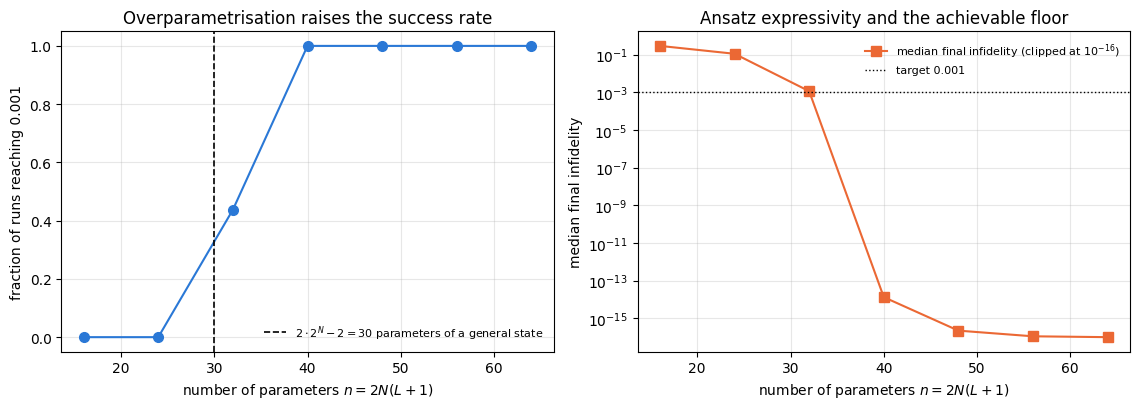

In [20]:
# ==============================================================================
# STEP 16: success probability against circuit depth
# ==============================================================================
N_D, N_RUNS_D, N_STEPS_D, TARGET_D = 4, 32, 400, 1e-3
target_haar = haar_state(jax.random.PRNGKey(777), N_D)
print(f"target: Haar-random state of N={N_D} qubits "
      f"(needs 2*2^N-2 = {2 * 2 ** N_D - 2} real parameters to specify)")
print(f"{'L':>3s} {'n = 2N(L+1)':>12s} {'success rate':>13s} {'median final':>14s} {'best final':>13s} "
      f"{'median iters to target':>23s}")
depths, succ, medfin, mediter = [], [], [], []
for L in (1, 2, 3, 4, 5, 6, 7):
    n = hea_num_params(N_D, L)
    cost_d = jax.jit(lambda t, L=L: 1.0 - fidelity_pure(target_haar, hardware_efficient_ansatz(t, N_D, L)))
    th_d, ks_d = random_starts(N_RUNS_D, n, seed=600 + L)
    _, h = train_many(th_d, ks_d, grad_exact(cost_d), opt_adam(0.05), cost_d, N_STEPS_D)
    h = np.asarray(jax.block_until_ready(h))
    it = iterations_to(h, TARGET_D)
    ok = it > 0
    depths.append(L); succ.append(float(ok.mean())); medfin.append(float(np.median(h[:, -1])))
    mediter.append(float(np.median(it[ok])) if ok.any() else np.nan)
    mi = f"{mediter[-1]:.0f}" if np.isfinite(mediter[-1]) else "-"
    print(f"{L:3d} {n:12d} {succ[-1]:13.2f} {medfin[-1]:14.2e} {float(np.min(h[:, -1])):13.2e} {mi:>23s}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ns = [hea_num_params(N_D, L) for L in depths]
axes[0].plot(ns, succ, MARKERS[0] + "-", ms=7, color=PALETTE[0])
axes[0].axvline(2 * 2 ** N_D - 2, color="k", ls="--", lw=1.2,
                label=f"$2\\cdot2^N-2={2 * 2 ** N_D - 2}$ parameters of a general state")
axes[0].set_xlabel("number of parameters $n=2N(L+1)$"); axes[0].set_ylabel(f"fraction of runs reaching {TARGET_D:g}")
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title("Overparametrisation raises the success rate"); axes[0].legend(fontsize=8)

axes[1].semilogy(ns, np.maximum(medfin, 1e-16), MARKERS[1] + "-", ms=7, color=PALETTE[1],
                 label="median final infidelity (clipped at $10^{-16}$)")
axes[1].axhline(TARGET_D, color="k", ls=":", lw=1, label=f"target {TARGET_D:g}")
axes[1].set_xlabel("number of parameters $n=2N(L+1)$"); axes[1].set_ylabel("median final infidelity")
axes[1].set_title("Ansatz expressivity and the achievable floor"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The measurement separates two distinct effects that are easy to confuse, and the counting argument predicts where the
boundary between them lies.

* **Expressivity.** At $L=1$ and $L=2$ the ansatz has $n=16$ and $n=24$ angles, fewer than the $30$ needed to specify a
  general four-qubit state. The image of the ansatz is then a lower-dimensional subset of the state manifold, and a
  Haar-random target lies outside it with probability one. All 32 runs end at the same infidelity, $0.29$ and $0.11$
  respectively, which is very likely the best the circuit can do (the runs agree to the printed digits), but 32 runs
  are not a proof of a global minimum. The right panel shows this as a high plateau.
* **Trainability.** At $L=3$, $n=32$ crosses the counting threshold of $30$, and the success rate jumps from $0$ to
  $14/32=0.44$ (95% interval $[0.28,0.61]$), with the successful runs needing a median of $306$ iterations. The target
  is now reachable, but fewer than half the random starts find it within 400 iterations. The budget matters here: the
  median final infidelity, $1.15\cdot10^{-3}$, sits just above the target, and in a separate check run outside this
  notebook, a further 3000 gradient-descent steps from the same end points raised the count from 14 to 17 of 32, while the
  $L=1$ and $L=2$ end points did not move (gradient norm below $2\cdot10^{-2}$, infidelity changed in the fourth
  digit), so those two levels are properties of the circuit and not of Adam's constant step. At $L=4$, $n=40$, the success
  rate is $32/32$ ($[0.89,1]$) and the median drops to $116$ iterations; by $L=7$, $n=64$, it is $61$. **Adding parameters
  beyond the minimum needed makes a reachable target easy to find**, and faster to find.

The vertical line in the left panel is the counting threshold $2\cdot2^N-2=30$, computed before the experiment. The rise
happens between the depths with $n=24$ and $n=32$, the two grid points that bracket it; the depth grid, in steps of
$2N=8$ parameters, cannot locate it more precisely.

This has to be weighed against Section 13 of notebook 40, where hardware-efficient circuits whose depth grows with $N$
were measured to have *exponentially smaller* gradient variances as $N$ grows. Depth helps trainability at fixed small
$N$ and hurts it as $N$ grows with the depth; which effect dominates has to be measured for the problem at hand.

## 15. Practical guidance, from this notebook's measurements only

The table below summarises what was measured here, on these two benchmarks, at these sizes. It is not a general ranking
of optimisers, and every entry can be re-derived from a printed number above.

| method | circuits per iteration | measured strength | measured weakness |
|---|---|---|---|
| gradient descent | $2n$ | stability threshold measured at twice the inverse largest curvature on both a quadratic and a circuit Hessian (Section 4) | slowest exact-gradient method in Section 12 (118 iterations against 56 for Adam); never reached the energy target, even in 3000 iterations (Section 13) |
| heavy-ball momentum | $2n$ | iteration count scales as the square root of the condition number (Section 5); admits a larger step than gradient descent, bound $2(1+\beta)/\lambda_{\max}$ (Section 11) | two hyper-parameters; on the energy landscape it needs more than 300 iterations to leave the saddle region (Section 13) |
| Adam | $2n$ | never diverges, step bounded by a few $\eta$ (Section 6.3); fewest circuits to target in Section 12; reached the energy target from 15 of 16 starts in 3000 iterations, with half the circuits of the natural gradient (Section 13) | 1 of 16 starts reached the energy target within 300 iterations; at most about 20% under fair tuning |
| SPSA with Spall gains | $2$ | cheapest possible iteration; the exponents derived from the convergence conditions (Section 7) | reached the target from 3 of 24 starts in Section 12 and from none in Section 13 |
| SPSA with Adam | $2$ | momentum averages the SPSA noise; its excess error from shot noise fell with the budget (Section 13) | did not reach the target in either benchmark within the iteration budget |
| quantum natural gradient | $2n+n(n+1)/2$ | fewest iterations in Section 12 (22); 15 of 16 starts reached the energy target within 300 iterations (Section 13); stable for $\eta<1$ on an infidelity cost, independently of the curvature (Section 11) | most circuits per iteration, 9 times Adam's at $n=32$ and 13 times at $n=48$; more circuits to target than Adam in both benchmarks; needs a ridge because the metric is singular |

Four decision rules that these measurements support:

* **On a simulator, use reverse-mode AD with Adam as the default.** The gradient is cheap (notebook 40, Section 11), so
  the per-iteration circuit count is irrelevant, and Adam has no divergence threshold and a usable step-size window of
  about a decade.
* **Try the natural gradient when the landscape has slow saddle regions.** On the energy landscape it reached the target
  from 15 of 16 starts in 300 iterations, where Adam reached it from 1 (and from at most about 20% at any step size);
  given ten times more iterations Adam reached it from 15 of 16, at half the circuit cost.
* **On hardware, the currency is circuit executions, and it re-ranks everything.** Moving from the iteration axis to the
  circuit axis of Section 12 shifts each exact-gradient curve by $\log_{10}64=1.8$ decades and the natural gradient by
  $\log_{10}592=2.8$ decades, against $0.3$ for SPSA.
* **Always run many initialisations, report the success rate with its interval, and state the iteration budget.** In
  Section 10 a single configuration produced final infidelities spanning ten orders of magnitude across 24 starts, and
  in Section 13 a success rate of 1/16 became 15/16 when the budget grew from 300 to 3000 iterations.

## 16. Key takeaways

* **The largest curvature sets a hard ceiling on the step size of gradient descent.** On a quadratic, gradient descent
  converges if and only if $\eta<2/\lambda_{\max}$, Eq. (5). The measured threshold was $0.40$ against a predicted
  $0.400$ on the test problem, and between $0.548$ and $0.592$ against a predicted $0.577$ on the Hessian of a real
  circuit landscape near a minimum. Heavy-ball momentum has the larger bound $2(1+\beta)/\lambda_{\max}$; Adam has no
  divergence threshold, because its step does not grow with the gradient.
* **The condition number sets the rate**, $\rho_\star=(\kappa-1)/(\kappa+1)$ for gradient descent and
  $(\sqrt\kappa-1)/(\sqrt\kappa+1)$ for heavy ball, Eqs. (6) and (9). Gradient-descent iteration counts matched the
  prediction to within one iteration over two and a half decades of $\kappa$; the ratio of the two methods' iteration
  counts grew as $\sqrt\kappa$ with a prefactor drifting from $0.83$ to $0.62$, a factor $20$ at $\kappa=1024$, the
  drift coming from the critically damped $(a+bk)\rho^k$ decay at the optimal heavy-ball parameters.
* **Adam's bias correction is a geometric sum**, Eq. (11). Without it the steps are *larger* than intended by a factor
  $(1-\beta_1^k)/\sqrt{1-\beta_2^k}$ that is $3.2$ at $k=1$, peaks at $6.6$ at $k=12$ and is still $3.2$ at $k=100$. Our
  from-scratch implementation reproduced the engine's bit for bit.
* **Spall's exponents follow from the convergence conditions.** Convergence requires $\alpha-\gamma>\tfrac12$, Eq. (15),
  and the asymptotic-normality theorem adds $\gamma\ge\alpha/6$; $(0.602,0.101)$ is effectively the lowest admissible
  pair, chosen so that the gains decay as slowly as the theory allows.
* **The quantum natural gradient measures distance in state space.** The Fubini–Study metric of Eq. (17) was validated
  four ways: the analytic $g=1/4$ of a single $R_y$, exact symmetry with a smallest eigenvalue of $-6\cdot10^{-17}$, the
  fidelity expansion of Eq. (16) to one power of $\delta$ per decade, and the identity Hessian $=2\mathbf G$ at an exact
  zero of the infidelity, which also gives the step-size bound $\eta<1$ for the natural gradient on such costs. Its
  kernel holds the parameter redundancy of the ansatz, which grows at special points such as the GHZ minimum.
* **Hyper-parameters must be measured, and they do not transfer.** Every optimiser's median final cost varied over
  orders of magnitude across the step-size grid, the optimum was different for each method, and Adam's best step moved
  from $0.13$ on the infidelity landscape to $0.45$ on the energy landscape of the same circuit family.
* **Per iteration and per circuit are different rankings.** The natural gradient won the first (22 iterations against
  Adam's 56 on the GHZ problem) and lost the second ($1.3\cdot10^4$ circuits against Adam's $3.6\cdot10^3$), because it
  pays $O(n^2)$ circuits for its metric.
* **A success rate depends on the iteration budget.** On the energy landscape, within 300 iterations the natural
  gradient reached the target from 15 of 16 starts and Adam from 1; the iterates of the Euclidean methods sit in saddle
  regions whose negative curvature is three thousand times weaker than the largest curvature, and the metric removes that
  disparity. With 3000 iterations Adam reached the target from 15 of 16 starts, with half the circuits of the natural
  gradient.
* **Shot noise adds an excess error at a fixed iteration count**, and the excess falls as the shot budget grows: parameter
  shift with Adam came within $5\%$ of its noise-free run at $512$ shots per energy estimate. The diagnostic to report is the
  exact cost of the state the optimiser produced, never the noisy estimate it was shown.
* **The variational principle is a free unit test.** Across every TFIM run recorded here the energy never fell below the
  Lanczos ground energy.
* **Success probability is the figure of merit, rather than the best run.** A single configuration produced final infidelities
  spanning ten orders of magnitude across 24 random starts, and the depth study showed the success rate rising from $0$
  to $0.44$ to $1.00$ as the parameter count crossed $2\cdot2^N-2=30$: extra parameters beyond the minimum needed make
  a hard target easy to find.

## 17. Exercises

1. ★ **The threshold to three digits.** Refine the learning-rate grid of Section 4.2 near $2/L$ and determine the threshold
   to three digits. Then repeat with $300$, $3000$ and $30000$ iterations: does the measured threshold move? Explain
   what "converged after $n$ steps" measures when $\eta$ is just below $2/L$.
2. ★ **Momentum without the optimum.** Fix $\beta=0.9$ (the practical default) and sweep $\eta$ on the test quadratic
   with $\kappa=256$. How close does the best $\eta$ at fixed $\beta$ come to the $\sqrt\kappa$ rate of Eq. (9)?
3. ★★ **Nesterov (extend the code).** Implement Nesterov's accelerated gradient — evaluate the gradient at
   $\boldsymbol\theta_k-\eta\beta\mathbf v_k$ instead of at $\boldsymbol\theta_k$ — as a third optimiser in the
   framework of Step 1, and add it to the benchmark of Section 12. On which of the two panels does it help?
4. ★★ **L-BFGS versus the rest (extend the code).** `scipy.optimize.minimize(method="L-BFGS-B", jac=...)` accepts the
   exact gradient. Run it from the same 24 initialisations as Section 12 (loop in Python; it cannot be vmapped) and
   add its iteration and function-evaluation counts to the table. Then repeat with a shot-noisy cost and explain what
   goes wrong.
5. ★★ **The SPSA gain constants.** Sweep $a$ and $c$ of Section 12's SPSA row on a two-dimensional grid and plot the
   median final infidelity as a heat map. Which of the two matters more, and how does the answer change when the cost
   is shot-noisy?
6. ★★ **Block-diagonal natural gradient (extend the code).** Replace the full metric by its block-diagonal
   approximation, with one block for each layer of $R_y$ gates and one for each layer of $R_z$ gates (so that the
   generators inside a block commute), as used in hardware implementations. Compare the iteration count with the full
   metric, and count the circuits each would need.
7. ★★★ **Overparametrisation at larger $N$ (physics).** Repeat Section 14 for $N=5$ and $N=6$ with a Haar-random
   target. Does the parameter count at which the success rate rises track $2\cdot2^N-2$? Combine the answer with the
   barren-plateau exponents of notebook 40 and state the regime in which both requirements can be met at once.
8. ★★★ **An optimiser that spends its shots adaptively (extend the code).** Make the shot budget per iteration grow
   with $k$ (for instance $M_k\propto k$) at a fixed *total* budget, and compare with the constant-$M$ runs of
   Section 13 at the same total number of shots. Does spending more shots late beat spending them uniformly?

## References

* J. C. Spall, *Multivariate stochastic approximation using a simultaneous perturbation gradient approximation*,
  IEEE Trans. Autom. Control **37**, 332 (1992) — SPSA, the conditions of Eq. (13), the power-law gains of Eq. (14)
  (without the stability constant $A$) and the asymptotic-normality conditions quoted in Section 7.2.
* J. C. Spall, *Implementation of the simultaneous perturbation algorithm for stochastic optimization*, IEEE Trans.
  Aerosp. Electron. Syst. **34**, 817 (1998) — the practical exponents $\alpha=0.602$, $\gamma=0.101$ as the lowest
  values allowed by the theory, the asymptotically optimal pair $(1,1/6)$, and the guideline for $A$ (Section 7.2).
* H. Robbins and S. Monro, *A stochastic approximation method*, Ann. Math. Statist. **22**, 400 (1951) — the iteration
  with decreasing gains that finds a root from noisy measurements (Section 7).
* B. T. Polyak, *Some methods of speeding up the convergence of iteration methods*, USSR Comput. Math. Math. Phys.
  **4**(5), 1 (1964) — the heavy-ball method of Eq. (7).
* D. P. Kingma and J. Ba, *Adam: a method for stochastic optimization*, 3rd International Conference on Learning
  Representations (ICLR 2015), arXiv:1412.6980 — the update equations of Eq. (10) and the bias correction of Eq. (11).
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific
  Computing*, 3rd ed. (Cambridge University Press, 2007), Chapter 10 — minimisation; §10.8 conjugate gradients and
  §10.9 quasi-Newton (variable-metric, BFGS) methods (Exercise 4).
* J. Stokes, J. Izaac, N. Killoran and G. Carleo, *Quantum natural gradient*, Quantum **4**, 269 (2020) — the
  Fubini–Study metric of Eq. (17), the update of Eq. (18) (with the pseudo-inverse of the metric in place of the ridge)
  and the block-diagonal approximation.
* J. Gacon, C. Zoufal, G. Carleo and S. Woerner, *Simultaneous perturbation stochastic approximation of the quantum
  Fisher information*, Quantum **5**, 567 (2021) — a constant-cost stochastic estimator of the metric, the alternative
  to the $O(n^2)$ overlap circuits of Section 9.
* J. R. McClean, J. Romero, R. Babbush and A. Aspuru-Guzik, *The theory of variational hybrid quantum-classical
  algorithms*, New J. Phys. **18**, 023023 (2016) — the hybrid loop and the role of the classical optimiser.
* A. Peruzzo, J. McClean, P. Shadbolt, M.-H. Yung, X.-Q. Zhou, P. J. Love, A. Aspuru-Guzik and J. L. O'Brien,
  *A variational eigenvalue solver on a photonic quantum processor*, Nat. Commun. **5**, 4213 (2014) — the first
  experiment of this kind.
* A. Kandala, A. Mezzacapo, K. Temme, M. Takita, M. Brink, J. M. Chow and J. M. Gambetta, *Hardware-efficient
  variational quantum eigensolver for small molecules and quantum magnets*, Nature **549**, 242 (2017) — the
  hardware-efficient ansatz family (layers of single-qubit rotations and native entangling gates) used in both
  benchmarks, and SPSA as the optimiser on hardware.
* M. Cerezo, A. Arrasmith, R. Babbush, S. C. Benjamin, S. Endo, K. Fujii, J. R. McClean, K. Mitarai, X. Yuan,
  L. Cincio and P. J. Coles, *Variational quantum algorithms*, Nat. Rev. Phys. **3**, 625 (2021) — the review, with a
  survey of optimisers and of trainability.
* J. R. McClean, S. Boixo, V. N. Smelyanskiy, R. Babbush and H. Neven, *Barren plateaus in quantum neural network
  training landscapes*, Nat. Commun. **9**, 4812 (2018) — why gradient-based training cannot leave an exponentially flat
  landscape with a polynomial number of measurements.
* M. Larocca, N. Ju, D. García-Martín, P. J. Coles and M. Cerezo, *Theory of overparametrization in quantum neural
  networks*, Nat. Comput. Sci. **3**, 542 (2023) — overparametrisation and the disappearance of spurious local minima
  (Section 14).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/